In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from pandas_profiling import ProfileReport
import seaborn as sns
from datetime import datetime

In [4]:
#rutas
ruta_dataset_finales =''
ruta_dataset_profile =''
ruta_dataset_splitting = ''
ruta_dataset_feature_creation = ''


In [5]:
#para gráficos
sns.set_theme()
sns.set_style({"xtick.bottom": True, "ytick.left": True})
paleta=['#081d58','#253494','#225ea8','#1d91c0','#41b6c4','#7fcdbb','#c7e9b4','#edf8b1','#ffffd9']
paleta1=['#225ea8']
paleta2=['#225ea8','#41b6c4']

## Nuevas variables para el dataset Procesos

In [ ]:
data_procesos=pd.read_csv(ruta_dataset_splitting+"procesos2016_2022_splitting.csv", sep='|', encoding='utf-8-sig')

In [8]:
data_procesos

,Unnamed: 0,num_proceso,Expediente,nombre_proceso,tipo_proceso,fecha_apertura,estado,unidad_ejecutora,servicio_administrativo_financiero,Unnamed: 0.1,...,ofertas_confirmadas,año_publicacion,año_apertura,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,periodo_acto_apertura
0,0,23-0009-LPR16,EX-2016-00697885- -APN-DPYS#SGP,Adquisición de elementos de electricidad,Licitación Privada,13/10/2016 13:02 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,0.0,...,5.0,2016,2016,201610,201609,201609,201610,201609,201610,201610
1,1,23-0010-LPR16,EX-2016-01031683- -APN-DPYS#SGP,Adquisición de elementos de plomería y cerraje...,Licitación Privada,13/09/2016 11:00 Hrs.,Desierto,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,1.0,...,0.0,2016,2016,201609,201609,201609,201609,201609,201609,201609
2,2,23-0011-LPR16,EX-2016-01358346- -APN-DDMYA#SGP,ADQUISICIÓN INSUMOS PARA BAÑOS,Licitación Privada,19/12/2016 12:30 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,2.0,...,3.0,2016,2016,201612,201612,201612,201612,201612,201612,201612
3,3,23-0012-LPR16,EX-2016-01392005- -APN-DDMYA#SGP,"Servicio anual de mantenimiento, y controles m...",Licitación Privada,30/11/2016 16:31 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,3.0,...,5.0,2016,2016,201611,201611,201611,201611,201611,201611,201611
4,4,23-0014-LPU16,EX-2016-00474707- -APN-DPYS#SGP,Adquisición de indumentaria.,Licitación Pública,27/10/2016 12:00 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,4.0,...,6.0,2016,2016,201610,201609,201609,201610,201609,201610,201610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69681,70506,95-0189-CDI21,EX-2021-124397120- -APN-DCYC#MDS,CONTRATACIÓN DIRECTA CON UNA UNIVERSIDAD NACIO...,Contratación Directa,18/01/2022 10:00 Hrs.,Desierto,95/000 - Dirección General de Administración -...,311 - Ministerio de Desarrollo Social,12.0,...,0.0,2022,2022,202201,202201,202201,202201,sin datos,sin datos,202201
69682,70507,96-0054-CDI22,EX-2022-44338308- -APN-DC#HP,"ADQUISICIÓN DE ÁCIDO 2,3 - DIMERCAPTOSUCCÍNICO...",Contratación Directa,21/06/2022 13:00 Hrs.,Desierto,96 - Dirección General de Administración,908 - Hospital Nacional Profesor Alejandro Pos...,33.0,...,0.0,2022,2022,202206,202206,202206,202206,sin datos,sin datos,202206
69683,70508,96-0118-CDI22,EX-2022-121335498- -APN-DC#HP,CALIBRACIÓN DE EQUIPAMIENTO Y ELEMENTOS DE MED...,Contratación Directa,23/11/2022 13:00 Hrs.,Desierto,96 - Dirección General de Administración,908 - Hospital Nacional Profesor Alejandro Pos...,42.0,...,0.0,2022,2022,202211,202211,202211,202211,sin datos,sin datos,202211
69684,70509,98-0012-CDI22,EX-2022-44810023- -APN-DA#FMLCAV,ADQUISICIÓN DE VACUNAS ANTIGRIPALES,Contratación Directa,16/05/2022 11:00 Hrs.,Desierto,98/00 - Dir. Compras,101 - Fundación Miguel Lillo,36.0,...,0.0,2022,2022,202205,202205,202205,202205,sin datos,sin datos,202205


#### dias_recepción_doc_soporte_fisico

In [9]:
#crea la variable días de recepción de la documentación en soporte físico, como la diferencia entre cro_fecha_inicio_recepcion_documentos, cro_fecha_fin_recepcion_documentos
#1-se vuelve a poner en nulo el sin datos para poder realizar operaciones fecha

data_procesos['cro_fecha_fin_recepcion_documentos']=data_procesos['cro_fecha_fin_recepcion_documentos'].replace('sin datos', np.nan)
data_procesos['cro_fecha_inicio_recepcion_documentos']=data_procesos['cro_fecha_inicio_recepcion_documentos'].replace('sin datos', np.nan)
#2- crea la nueva variable
data_procesos['date_fecha_final_doc'] = pd.to_datetime(data_procesos['cro_fecha_fin_recepcion_documentos'].astype(str).str[:10], format="%d/%m/%Y") 
data_procesos['date_fecha_final_doc']=data_procesos['date_fecha_final_doc'].astype('datetime64[ns]')
data_procesos['date_fecha_inicio_doc'] = pd.to_datetime(data_procesos['cro_fecha_inicio_recepcion_documentos'].astype(str).str[:10], format="%d/%m/%Y") 
data_procesos['date_fecha_inicio_doc']=data_procesos['date_fecha_inicio_doc'].astype('datetime64[ns]')
data_procesos['dias_recepción_doc_soporte_fisico'] = (data_procesos['date_fecha_final_doc'] - data_procesos['date_fecha_inicio_doc'])/ np.timedelta64(1, 'D')

data_procesos.drop('date_fecha_final_doc', inplace=True, axis=1)
data_procesos.drop('date_fecha_inicio_doc', inplace=True, axis=1)
#3-completa con 'sin datos' los valores nulos

data_procesos['cro_fecha_fin_recepcion_documentos']=data_procesos['cro_fecha_fin_recepcion_documentos'].fillna("sin datos")
data_procesos['cro_fecha_inicio_recepcion_documentos']=data_procesos['cro_fecha_inicio_recepcion_documentos'].fillna("sin datos")
data_procesos['dias_recepción_doc_soporte_fisico'] =data_procesos['dias_recepción_doc_soporte_fisico'] .fillna('sin datos')

In [14]:
#para calcular estadísticos
data_procesos['dias_recepción_doc_soporte_fisico']=data_procesos['dias_recepción_doc_soporte_fisico'].replace('sin datos', np.nan)
data_procesos['dias_recepción_doc_soporte_fisico'].describe()
mediana = data_procesos['dias_recepción_doc_soporte_fisico'].median()
print(mediana)

8.0


#### dias_contrato

In [7]:
#Crea la variable días total contrato

#extrae número de un string
data_procesos['dias_contrato']=data_procesos['duracion_contrato'].astype('str').str.extractall('(\d+)').unstack().fillna('').sum(axis=1).astype(int)
data_procesos['modo_contrato'] = data_procesos['duracion_contrato'].str.extract(r'\b(\w+)$', 
                                     expand = True)

data_procesos.loc[data_procesos['modo_contrato'] == 'Meses', 'multiplicador'] = 30
data_procesos.loc[data_procesos['modo_contrato'] == 'Mes', 'multiplicador'] = 30
data_procesos.loc[data_procesos['modo_contrato'] == 'corridos', 'multiplicador'] = 1
data_procesos.loc[data_procesos['modo_contrato'] == 'corrido', 'multiplicador'] = 1
data_procesos.loc[data_procesos['modo_contrato'] == 'hábiles', 'multiplicador'] = 1.4
data_procesos.loc[data_procesos['modo_contrato'] == 'hábil', 'multiplicador'] = 1.4
data_procesos.loc[data_procesos['modo_contrato'] == 'Años', 'multiplicador'] = 365
data_procesos.loc[data_procesos['modo_contrato'] == 'Año', 'multiplicador'] = 365

data_procesos['duracion_contrato_dias'] = (data_procesos['dias_contrato'] * data_procesos['multiplicador']).apply(np.ceil)

data_procesos.drop('dias_contrato', inplace=True, axis=1)
data_procesos.drop('modo_contrato', inplace=True, axis=1)
data_procesos.drop('multiplicador', inplace=True, axis=1)

#### cat_inicio_contrato

In [8]:
#Nueva discretización de inicio contrato
#obtiene el dato numérico
data_procesos['inicio_dias']= data_procesos['inicio_contrato'].astype('str').str.extractall('(\d+)').unstack().fillna('').sum(axis=1).astype(int)
data_procesos['inicio_dias']


#pokemon_games = data_procesos.loc[data_procesos['Name'].str.contains("pokemon", case=False)]
data_procesos['clase'] = np.where(data_procesos['inicio_contrato'].str.contains("corridos", case=True), 1,
                       (np.where(data_procesos['inicio_contrato'].str.contains("corrido", case=True), 1,
                              np.where(data_procesos['inicio_contrato'].str.contains("hábil", case=True), 1.4,
                                       np.where(data_procesos['inicio_contrato'].str.contains("hábiles", case=True), 1.4,0
                                                )))))

data_procesos['dias_inicio_total'] = (data_procesos['inicio_dias'] * data_procesos['clase']).apply(np.ceil)


#se obtiene el texto de inicio
data_procesos['inicio_6letras']= data_procesos['inicio_contrato'].astype('str').str[:6]
data_procesos['inicio_6letras']

#se agrega el texto "siguiente" para los casos dónde el inicio es el mes siguiente
data_procesos['inicio_6letras2'] = data_procesos['inicio_6letras'] + np.where(data_procesos['inicio_contrato'].str.contains("siguiente", case=True), 'siguiente','')



In [9]:
def inicio_contrato_categorise(row):  
    if row['inicio_6letras2'] == 'A part':
        return 'A partir del perfeccionamiento del documento contractual'
    elif row['inicio_6letras2'] =='A los siguiente' and row['dias_inicio_total'] <= 10:
        return 'Entre los 10 primeros Días del mes siguiente del perfeccionamiento del documento contractual'
    elif row['inicio_6letras2'] =='A los siguiente' and row['dias_inicio_total'] > 10:
        return 'Después de 10 Días del mes siguiente del perfeccionamiento del documento contractual'    
    elif row['inicio_6letras2'] =='Dentro' and row['dias_inicio_total'] <= 10:
        return 'Dentro de los 10 Días del perfeccionamiento del documento contractual'
    elif row['inicio_6letras2'] =='Dentro' and row['dias_inicio_total'] > 10 and row['dias_inicio_total'] <= 15:
        return 'Entre 11 y 15 Días del perfeccionamiento del documento contractual'
    elif row['inicio_6letras2'] =='Dentro' and row['dias_inicio_total'] > 15 and row['dias_inicio_total'] <= 30:
        return 'Entre 16 y 30 Días del perfeccionamiento del documento contractual'
    elif row['inicio_6letras2'] =='Dentro' and row['dias_inicio_total'] > 30:
        return 'Más de 30 Días del perfeccionamiento del documento contractual'
    elif row['inicio_6letras2'] =='A los ' and row['dias_inicio_total'] <= 10:
        return 'Entre los 10 primeros Días del mes siguiente del perfeccionamiento del documento contractual'
    elif row['inicio_6letras2'] =='A los ' and row['dias_inicio_total'] > 10:
        return 'Después de 10 Días del mes siguiente del perfeccionamiento del documento contractual' 


In [10]:
#nueva categorización de inicio contrato
data_procesos['cat_inicio_contrato'] = data_procesos.apply(lambda row: inicio_contrato_categorise(row), axis=1)

In [11]:
data_procesos.drop('inicio_6letras2', inplace=True, axis=1)
data_procesos.drop('dias_inicio_total', inplace=True, axis=1)
data_procesos.drop('inicio_6letras', inplace=True, axis=1)
data_procesos.drop('clase', inplace=True, axis=1)
data_procesos.drop('inicio_dias', inplace=True, axis=1)

In [12]:
data_procesos['duracion_contrato_dias'].describe()

count     69276.000000
mean        182.160272
std        1417.610637
min           1.000000
25%          28.000000
50%          90.000000
75%         360.000000
max      364635.000000
Name: duracion_contrato_dias, dtype: float64

In [13]:
procesosXinicioContrato=data_procesos.groupby(['cat_inicio_contrato']).size().reset_index(name='num')
procesosXinicioContrato['total']=data_procesos['cat_inicio_contrato'].count()
procesosXinicioContrato['percent']=procesosXinicioContrato['num']/procesosXinicioContrato['total']*100
#crea variable que indica que agrupar para agrupar
procesosXinicioContrato.loc[procesosXinicioContrato['percent'] < 1.0, 'agrupador'] = 'Otros'
procesosXinicioContrato.loc[procesosXinicioContrato['percent'] > 1.0, 'agrupador'] = procesosXinicioContrato['cat_inicio_contrato']
procesosXinicioContrato = procesosXinicioContrato.sort_values("percent", ascending=False)

procesosXinicioContrato

,cat_inicio_contrato,num,total,percent,agrupador
0,A partir del perfeccionamiento del documento c...,45130,69668,64.778665,A partir del perfeccionamiento del documento c...
5,Entre los 10 primeros Días del mes siguiente d...,7472,69668,10.725154,Entre los 10 primeros Días del mes siguiente d...
1,Dentro de los 10 Días del perfeccionamiento de...,4487,69668,6.440547,Dentro de los 10 Días del perfeccionamiento de...
4,Entre 16 y 30 Días del perfeccionamiento del d...,4485,69668,6.437676,Entre 16 y 30 Días del perfeccionamiento del d...
3,Entre 11 y 15 Días del perfeccionamiento del d...,3907,69668,5.608027,Entre 11 y 15 Días del perfeccionamiento del d...
6,Más de 30 Días del perfeccionamiento del docum...,2342,69668,3.361658,Más de 30 Días del perfeccionamiento del docum...
2,Después de 10 Días del mes siguiente del perfe...,1845,69668,2.648275,Después de 10 Días del mes siguiente del perfe...


#### se va a agregar información de los bienes o servicios adquiridos en el proceso de compra

### Items

In [14]:
data_items=pd.read_csv(ruta_dataset_splitting+"items2016_2022_splitting.csv", sep='|', encoding='utf-8-sig')

In [15]:
data_items

,num_expediente,num_proceso,objeto_del_gasto,codigo_del_item,descripcion,rubro,clase,item,estado,objeto_compra,cantidad
0,EX-2016-01358346- -APN-DDMYA#SGP,23-0011-LPR16,2.3.4,2.3.4-783.40,"TOALLAS DE PAPEL - MATERIAL: PAPEL, GRAMAJE: S...",ELEMENTOS DE LIMPIEZA,TOALLAS DE PAPEL,"TOALLAS DE PAPEL - MATERIAL: PAPEL, GRAMAJE: S...",Activo,BIEN,2640.0
1,EX-2016-01358346- -APN-DDMYA#SGP,23-0011-LPR16,2.3.4,2.3.4-786.59,PAPEL HIGIENICO - PRESENTACION: PAQUETE X 8 UN...,ELEMENTOS DE LIMPIEZA,PAPEL HIGIENICO,PAPEL HIGIENICO - PRESENTACION: PAQUETE X 8 UN...,Activo,BIEN,2400.0
2,EX-2016-01358346- -APN-DDMYA#SGP,23-0011-LPR16,2.9.1,2.9.1-6956.92,"ARTICULOS DE TOCADOR - TIPO: JABON LIQUIDO, PR...",ELEMENTOS DE LIMPIEZA,ARTICULOS DE TOCADOR,"ARTICULOS DE TOCADOR - TIPO: JABON LIQUIDO, PR...",Activo,BIEN,2400.0
3,EX-2016-00549712- -APN-DPYS#SGP,23-0015-LPU16,3.5.1,3.5.1-4971.1,SERV. TRANSPORTE DE PERSONAS - DESCRIPCION: SE...,SERV. PROFESIONAL Y COMERCIAL,SERV. TRANSPORTE DE PERSONAS,SERV. TRANSPORTE DE PERSONAS - DESCRIPCION: SE...,Activo,SERVICIO,81000.0
4,EX-2016-00549712- -APN-DPYS#SGP,23-0015-LPU16,3.5.1,3.5.1-4971.1,SERV. TRANSPORTE DE PERSONAS - DESCRIPCION: SE...,SERV. PROFESIONAL Y COMERCIAL,SERV. TRANSPORTE DE PERSONAS,SERV. TRANSPORTE DE PERSONAS - DESCRIPCION: SE...,Activo,SERVICIO,9000.0
...,...,...,...,...,...,...,...,...,...,...,...
1086794,EX-2022-82199786- -APN-CAE#EA,84/7-1289-LPR22,3.3.2,3.3.2-5266.21,MANT. Y REP. DE VEHICULOS - DESCRIPCION: MANT....,MANT. REPARACION Y LIMPIEZA,MANT. Y REP. DE VEHICULOS,MANT. Y REP. DE VEHICULOS - DESCRIPCION: MANT....,Activo,SERVICIO,1.0
1086795,EX-2022-82199786- -APN-CAE#EA,84/7-1289-LPR22,3.3.2,3.3.2-5266.21,MANT. Y REP. DE VEHICULOS - DESCRIPCION: MANT....,MANT. REPARACION Y LIMPIEZA,MANT. Y REP. DE VEHICULOS,MANT. Y REP. DE VEHICULOS - DESCRIPCION: MANT....,Activo,SERVICIO,1.0
1086796,EX-2022-94849636- -APN-DCYF#EA,84/77-0160-CDI22,4.3.9,4.3.9-3098.6,"RECEPTORES SATELITALES - TIPO: PORTATIL, USO: ...",EQUIPOS,RECEPTORES SATELITALES,"RECEPTORES SATELITALES - TIPO: PORTATIL, USO: ...",Activo,BIEN,6.0
1086797,EX-2022-86079882- -APN-SGAYF#INCAA,87-0054-CDI22,3.2.9,3.2.9-2621.1,ALQ. DE UTILES P/EVENTO - DESCRIPCION: ALQUILE...,ALQUILER,ALQ. DE UTILES P/EVENTO,ALQ. DE UTILES P/EVENTO; DESCRIPCION: ALQUILER...,Activo,SERVICIO,1.0


#### cant_total_bienes y cant_total_servicios

In [16]:
#se crea la variable cantidad de bienes y servicios que se adquieren por cada proceso de compra.
#agrupar para cada proceso de compra
#contar cuantos son Bienes - Servicios

data_items['total'] = data_items.groupby(['num_proceso','objeto_compra'])['cantidad'].transform("sum")

#crear variable total Bienes y Total para servicios
data_items['cant_total_bienes'] = np.where(data_items['objeto_compra']== 'BIEN',data_items["total"] ,0)
data_items['cant_total_servicios'] = np.where(data_items['objeto_compra']== ' SERVICIO',data_items["total"] ,0)


#reducir items para obtener para cada proceso la info relativa a los items

proceso_item = data_items[['num_proceso','cant_total_bienes','cant_total_servicios']]

#quitar duplicados
proceso_item = proceso_item.drop_duplicates()


#unificar totales en una sola fila para el caso de que un mismo proceso tenga bienes y servicios

proceso_item["cant_total_bienes"] = proceso_item.groupby(["num_proceso"])["cant_total_bienes"].transform("sum")

proceso_item["cant_total_servicios"] = proceso_item.groupby(["num_proceso"])["cant_total_servicios"].transform("sum")

#quitar duplicados
proceso_item = proceso_item.drop_duplicates()


#### tipo_adquisicion

In [17]:
data_procesos = data_procesos.merge(proceso_item, on='num_proceso', how='left')

#se crea la variable tipo adquisición: Bienes - Servicios - Mixto
data_procesos['tipo_adquisicion']= np.where((data_procesos['cant_total_bienes'] > 0.0 ) & (data_procesos['cant_total_servicios'] == 0.0) ,'BIEN' ,'SERVICIO')
data_procesos['tipo_adquisicion']= np.where((data_procesos['cant_total_bienes'] > 0.0) & (data_procesos['cant_total_servicios'] > 0.0) ,'MIXTO' ,data_procesos['tipo_adquisicion'])                                           

In [18]:
#grafica tipo adquisición

tipoAdq=data_procesos.groupby(['tipo_adquisicion']).size().reset_index(name='num')
tipoAdq['total']=data_procesos['tipo_adquisicion'].count()
tipoAdq['percent']=tipoAdq['num']/tipoAdq['total']*100
#crea variable que indica que agrupar para agrupar
tipoAdq.loc[tipoAdq['percent'] < 1.0, 'agrupador'] = 'Otros'
tipoAdq.loc[tipoAdq['percent'] > 1.0, 'agrupador'] = tipoAdq['tipo_adquisicion']
tipoAdq = tipoAdq.sort_values("percent", ascending=False)

tipoAdq

,tipo_adquisicion,num,total,percent,agrupador
0,BIEN,38900,69686,55.821829,BIEN
2,SERVICIO,28715,69686,41.206268,SERVICIO
1,MIXTO,2071,69686,2.971903,MIXTO


In [19]:
df =tipoAdq.groupby(['agrupador'])['percent'].sum().reset_index()
df = df.sort_values("percent", ascending=False)
    #estadoXcant['Group'] = estadoXcant.groupby(['estado'])['Nro procesos'].sum()
df

,agrupador,percent
0,BIEN,55.821829
2,SERVICIO,41.206268
1,MIXTO,2.971903


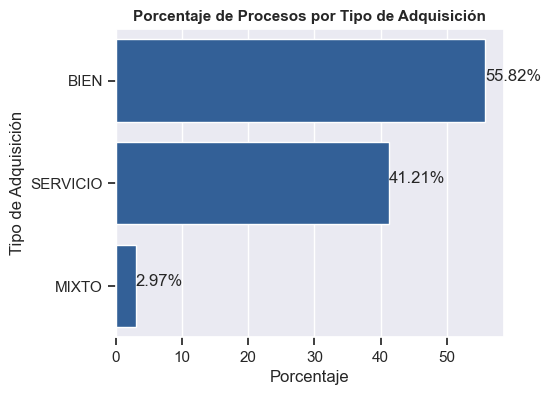

In [20]:
plt.figure(figsize=(5, 4))
sns.set_palette(paleta1)
g = sns.barplot(data=df, y='agrupador',x='percent', palette=paleta1)
g.set_title('Porcentaje de Procesos por Tipo de Adquisición', fontweight='bold',size=11)
g.set(xlabel='Porcentaje', ylabel='Tipo de Adquisición')

total = len(df['percent'])
for p in g.patches:
        percentage = '{:.2f}%'.format(p.get_width())
        x = p.get_x() + p.get_width() + 0.01
        y = p.get_y() + p.get_height()/2
        g.annotate(percentage, (x, y))

#### total_rubro 

In [93]:
#agrupar para cada proceso de compra
#contar cantidades por rubro

data_items['total_rubro'] = data_items.groupby(['num_proceso','rubro'])['cantidad'].transform("sum")

#crear variable total Bienes y Total para servicios
data_items['TOT_AGROPECUARIO'] = np.where(data_items['rubro']== 'AGRIC,GANADERIA,CAZA,SILVICULT',data_items["total_rubro"] ,0)
data_items['TOT_ALIMENTOS'] = np.where(data_items['rubro']== 'ALIMENTOS',data_items["total_rubro"] ,0)
data_items['TOT_ALQUILER'] = np.where(data_items['rubro']== 'ALQUILER',data_items["total_rubro"] ,0)
data_items['TOT_ART_HOGAR'] = np.where(data_items['rubro']== 'ARTICULOS DEL HOGAR',data_items["total_rubro"] ,0)
data_items['TOT_BANCO'] = np.where(data_items['rubro']== 'BANCOS Y SEGUROS',data_items["total_rubro"] ,0)
data_items['TOT_BAZAR'] = np.where(data_items['rubro']== 'BAZAR Y MENAJE',data_items["total_rubro"] ,0)
data_items['TOT_CARPINTERIA'] = np.where(data_items['rubro']== 'CARPINTERIA',data_items["total_rubro"] ,0)
data_items['TOT_CEREMONIAL'] = np.where(data_items['rubro']== 'CEREMONIAL',data_items["total_rubro"] ,0)
data_items['TOT_CERRAJERIA'] = np.where(data_items['rubro']== 'CERRAJERIA',data_items["total_rubro"] ,0)
data_items['TOT_CINE'] = np.where(data_items['rubro']== 'CINE/TELVIS./RADIO/FOTOGRAFIA',data_items["total_rubro"] ,0)
data_items['TOT_COMBUSTIBLES'] = np.where(data_items['rubro']== 'COMBUSTIBLES Y LUBRICANTES',data_items["total_rubro"] ,0)
data_items['TOT_CONCESION'] = np.where(data_items['rubro']== 'CONCESION',data_items["total_rubro"] ,0)
data_items['TOT_CONSTRUCCION'] = np.where(data_items['rubro']== 'CONSTRUCCION',data_items["total_rubro"] ,0)
data_items['TOT_CULTURA'] = np.where(data_items['rubro']== 'CULTURA',data_items["total_rubro"] ,0)
data_items['TOT_ELECTRICIDAD'] = np.where(data_items['rubro']== 'ELECTRICIDAD Y TELEFONIA',data_items["total_rubro"] ,0)
data_items['TOT_LIMPIEZA'] = np.where(data_items['rubro']== 'ELEMENTOS DE LIMPIEZA',data_items["total_rubro"] ,0)
data_items['TOT_MUEBLES'] = np.where(data_items['rubro']== 'EQUIPO DE OFICINA Y MUEBLES',data_items["total_rubro"] ,0)
data_items['TOT_EQUIPO_MILITAR'] = np.where(data_items['rubro']== 'EQUIPO MILITAR Y DE SEGURIDAD',data_items["total_rubro"] ,0)
data_items['TOT_EQUIPOS'] = np.where(data_items['rubro']== 'EQUIPOS',data_items["total_rubro"] ,0)
data_items['TOT_FERRETERIA'] = np.where(data_items['rubro']== 'FERRETERIA',data_items["total_rubro"] ,0)
data_items['TOT_GASES_IND'] = np.where(data_items['rubro']== 'GASES INDUSTRIALES',data_items["total_rubro"] ,0)
data_items['TOT_HERRAMIENTAS'] = np.where(data_items['rubro']== 'HERRAMIENTAS',data_items["total_rubro"] ,0)
data_items['TOT_HERRERIA'] = np.where(data_items['rubro']== 'HERRERIA',data_items["total_rubro"] ,0)
data_items['TOT_IMPRENTA'] = np.where(data_items['rubro']== 'IMPRENTA Y EDITORIALES',data_items["total_rubro"] ,0)
data_items['TOT_INDUMENTARIA'] = np.where(data_items['rubro']== 'INDUMENT TEXTIL Y CONFECCIONES',data_items["total_rubro"] ,0)
data_items['TOT_INFORMATICA'] = np.where(data_items['rubro']== 'INFORMATICA',data_items["total_rubro"] ,0)
data_items['TOT_INMUEBLES'] = np.where(data_items['rubro']== 'INMUEBLES',data_items["total_rubro"] ,0)
data_items['TOT_INSUMO_ARMAMENTO'] = np.where(data_items['rubro']== 'INSUMO P/ ARMAMENTO',data_items["total_rubro"] ,0)
data_items['TOT_JOYERIA'] = np.where(data_items['rubro']== 'JOYERIA Y ORFEBRERIA',data_items["total_rubro"] ,0)
data_items['TOT_LIBRERIA'] = np.where(data_items['rubro']== 'LIBRERIA,PAP. Y UTILES OFICINA',data_items["total_rubro"] ,0)
data_items['TOT_MANTENIMIENTO'] = np.where(data_items['rubro']== 'MANT. REPARACION Y LIMPIEZA',data_items["total_rubro"] ,0)
data_items['TOT_METALES'] = np.where(data_items['rubro']== 'METALES',data_items["total_rubro"] ,0)
data_items['TOT_METALURGIA'] = np.where(data_items['rubro']== 'METALURGIA',data_items["total_rubro"] ,0)
data_items['TOT_CONSTRUCCION'] = np.where(data_items['rubro']== 'MATERIALES DE CONSTRUCCION',data_items["total_rubro"] ,0)
data_items['TOT_NAUTICA'] = np.where(data_items['rubro']== 'NAUTICA',data_items["total_rubro"] ,0)
data_items['TOT_PINTURAS'] = np.where(data_items['rubro']== 'PINTURAS',data_items["total_rubro"] ,0)
data_items['TOT_PROD_MEDICOS'] = np.where(data_items['rubro']== 'PROD. MEDICO/FARMACEUTICOS/LAB',data_items["total_rubro"] ,0)
data_items['TOT_PROD_VETERINARIOS'] = np.where(data_items['rubro']== 'PRODUCTOS VETERINARIOS',data_items["total_rubro"] ,0)
data_items['TOT_QUIMICOS'] = np.where(data_items['rubro']== 'QUIMICOS',data_items["total_rubro"] ,0)
data_items['TOT_REPUESTOS'] = np.where(data_items['rubro']== 'REPUESTOS',data_items["total_rubro"] ,0)
data_items['TOT_PLOMERIA'] = np.where(data_items['rubro']== 'SANITARIOS, PLOMERIA Y GAS',data_items["total_rubro"] ,0)
data_items['TOT_SERV_PROFESIONAL'] = np.where(data_items['rubro']== 'SERV. PROFESIONAL Y COMERCIAL',data_items["total_rubro"] ,0)
data_items['TOT_SERV_NOTICIAS'] = np.where(data_items['rubro']== 'SERVICIO DE NOTICIAS',data_items["total_rubro"] ,0)
data_items['TOT_SERV_BASICOS'] = np.where(data_items['rubro']== 'SERVICIOS BASICOS',data_items["total_rubro"] ,0)
data_items['TOT_TAPICERIA'] = np.where(data_items['rubro']== 'TAPICERIA',data_items["total_rubro"] ,0)
data_items['TOT_TRANSPORTE'] = np.where(data_items['rubro']== 'TRANSPORTE Y DEPOSITO',data_items["total_rubro"] ,0)
data_items['TOT_PROD_DEPORTIVOS'] = np.where(data_items['rubro']== 'UTILES Y PRODUCTOS DEPORTIVOS',data_items["total_rubro"] ,0)
data_items['TOT_VIDRIERIA'] = np.where(data_items['rubro']== 'VIDRIERIA',data_items["total_rubro"] ,0)
data_items['TOT_VIGILANCIA'] = np.where(data_items['rubro']== 'VIGILANCIA Y SEGURIDAD',data_items["total_rubro"] ,0)


#reducir items para obtener para cada proceso la info relativa a los rubros que solicita comprar

proceso_item = data_items[['num_proceso','TOT_AGROPECUARIO', 'TOT_ALIMENTOS','TOT_ALQUILER','TOT_ART_HOGAR','TOT_BANCO','TOT_BAZAR','TOT_CARPINTERIA','TOT_CEREMONIAL','TOT_CERRAJERIA','TOT_CINE','TOT_COMBUSTIBLES','TOT_CONCESION','TOT_CONSTRUCCION','TOT_CULTURA','TOT_ELECTRICIDAD','TOT_LIMPIEZA','TOT_MUEBLES','TOT_EQUIPO_MILITAR','TOT_EQUIPOS','TOT_FERRETERIA','TOT_GASES_IND','TOT_HERRAMIENTAS','TOT_HERRERIA','TOT_IMPRENTA','TOT_INDUMENTARIA','TOT_INFORMATICA','TOT_INMUEBLES','TOT_INSUMO_ARMAMENTO','TOT_JOYERIA','TOT_LIBRERIA','TOT_MANTENIMIENTO','TOT_METALES','TOT_METALURGIA','TOT_CONSTRUCCION','TOT_NAUTICA','TOT_PINTURAS','TOT_PROD_MEDICOS','TOT_PROD_VETERINARIOS','TOT_QUIMICOS','TOT_REPUESTOS','TOT_PLOMERIA','TOT_SERV_PROFESIONAL','TOT_SERV_NOTICIAS','TOT_SERV_BASICOS','TOT_TAPICERIA','TOT_TRANSPORTE','TOT_PROD_DEPORTIVOS','TOT_VIDRIERIA','TOT_VIGILANCIA']]

#quitar duplicados
proceso_item = proceso_item.drop_duplicates()

#unificar totales en una sola fila para el caso de que un mismo proceso tenga distintos rubros 

proceso_item["TOT_AGROPECUARIO"] = proceso_item.groupby(["num_proceso"])["TOT_AGROPECUARIO"].transform("sum")
proceso_item["TOT_ALIMENTOS"] = proceso_item.groupby(["num_proceso"])["TOT_ALIMENTOS"].transform("sum")
proceso_item["TOT_ALQUILER"] = proceso_item.groupby(["num_proceso"])["TOT_ALQUILER"].transform("sum")
proceso_item["TOT_ART_HOGAR"] = proceso_item.groupby(["num_proceso"])["TOT_ART_HOGAR"].transform("sum")
proceso_item["TOT_BANCO"] = proceso_item.groupby(["num_proceso"])["TOT_BANCO"].transform("sum")
proceso_item["TOT_BAZAR"] = proceso_item.groupby(["num_proceso"])["TOT_BAZAR"].transform("sum")
proceso_item["TOT_CARPINTERIA"] = proceso_item.groupby(["num_proceso"])["TOT_CARPINTERIA"].transform("sum")
proceso_item["TOT_CEREMONIAL"] = proceso_item.groupby(["num_proceso"])["TOT_CEREMONIAL"].transform("sum")
proceso_item["TOT_CERRAJERIA"] = proceso_item.groupby(["num_proceso"])["TOT_CERRAJERIA"].transform("sum")
proceso_item["TOT_CINE"] = proceso_item.groupby(["num_proceso"])["TOT_CINE"].transform("sum")
proceso_item["TOT_COMBUSTIBLES"] = proceso_item.groupby(["num_proceso"])["TOT_COMBUSTIBLES"].transform("sum")
proceso_item["TOT_CONCESION"] = proceso_item.groupby(["num_proceso"])["TOT_CONCESION"].transform("sum")
proceso_item["TOT_CONSTRUCCION"] = proceso_item.groupby(["num_proceso"])["TOT_CONSTRUCCION"].transform("sum")
proceso_item["TOT_CULTURA"] = proceso_item.groupby(["num_proceso"])["TOT_CULTURA"].transform("sum")
proceso_item["TOT_ELECTRICIDAD"] = proceso_item.groupby(["num_proceso"])["TOT_ELECTRICIDAD"].transform("sum")
proceso_item["TOT_LIMPIEZA"] = proceso_item.groupby(["num_proceso"])["TOT_LIMPIEZA"].transform("sum")
proceso_item["TOT_MUEBLES"] = proceso_item.groupby(["num_proceso"])["TOT_MUEBLES"].transform("sum")
proceso_item["TOT_EQUIPO_MILITAR"] = proceso_item.groupby(["num_proceso"])["TOT_EQUIPO_MILITAR"].transform("sum")
proceso_item["TOT_EQUIPOS"] = proceso_item.groupby(["num_proceso"])["TOT_EQUIPOS"].transform("sum")
proceso_item["TOT_FERRETERIA"] = proceso_item.groupby(["num_proceso"])["TOT_FERRETERIA"].transform("sum")
proceso_item["TOT_GASES_IND"] = proceso_item.groupby(["num_proceso"])["TOT_GASES_IND"].transform("sum")
proceso_item["TOT_HERRAMIENTAS"] = proceso_item.groupby(["num_proceso"])["TOT_HERRAMIENTAS"].transform("sum")
proceso_item["TOT_HERRERIA"] = proceso_item.groupby(["num_proceso"])["TOT_HERRERIA"].transform("sum")
proceso_item["TOT_IMPRENTA"] = proceso_item.groupby(["num_proceso"])["TOT_IMPRENTA"].transform("sum")
proceso_item["TOT_INDUMENTARIA"] = proceso_item.groupby(["num_proceso"])["TOT_INDUMENTARIA"].transform("sum")
proceso_item["TOT_INFORMATICA"] = proceso_item.groupby(["num_proceso"])["TOT_INFORMATICA"].transform("sum")
proceso_item["TOT_INMUEBLES"] = proceso_item.groupby(["num_proceso"])["TOT_INMUEBLES"].transform("sum")
proceso_item["TOT_INSUMO_ARMAMENTO"] = proceso_item.groupby(["num_proceso"])["TOT_INSUMO_ARMAMENTO"].transform("sum")
proceso_item["TOT_JOYERIA"] = proceso_item.groupby(["num_proceso"])["TOT_JOYERIA"].transform("sum")
proceso_item["TOT_LIBRERIA"] = proceso_item.groupby(["num_proceso"])["TOT_LIBRERIA"].transform("sum")
proceso_item["TOT_MANTENIMIENTO"] = proceso_item.groupby(["num_proceso"])["TOT_MANTENIMIENTO"].transform("sum")
proceso_item["TOT_METALES"] = proceso_item.groupby(["num_proceso"])["TOT_METALES"].transform("sum")
proceso_item["TOT_METALURGIA"] = proceso_item.groupby(["num_proceso"])["TOT_METALURGIA"].transform("sum")
proceso_item["TOT_CONSTRUCCION"] = proceso_item.groupby(["num_proceso"])["TOT_CONSTRUCCION"].transform("sum")
proceso_item["TOT_NAUTICA"] = proceso_item.groupby(["num_proceso"])["TOT_NAUTICA"].transform("sum")
proceso_item["TOT_PINTURAS"] = proceso_item.groupby(["num_proceso"])["TOT_PINTURAS"].transform("sum")
proceso_item["TOT_PROD_MEDICOS"] = proceso_item.groupby(["num_proceso"])["TOT_PROD_MEDICOS"].transform("sum")
proceso_item["TOT_PROD_VETERINARIOS"] = proceso_item.groupby(["num_proceso"])["TOT_PROD_VETERINARIOS"].transform("sum")
proceso_item["TOT_QUIMICOS"] = proceso_item.groupby(["num_proceso"])["TOT_QUIMICOS"].transform("sum")
proceso_item["TOT_REPUESTOS"] = proceso_item.groupby(["num_proceso"])["TOT_REPUESTOS"].transform("sum")
proceso_item["TOT_PLOMERIA"] = proceso_item.groupby(["num_proceso"])["TOT_PLOMERIA"].transform("sum")
proceso_item["TOT_SERV_PROFESIONAL"] = proceso_item.groupby(["num_proceso"])["TOT_SERV_PROFESIONAL"].transform("sum")
proceso_item["TOT_SERV_NOTICIAS"] = proceso_item.groupby(["num_proceso"])["TOT_SERV_NOTICIAS"].transform("sum")
proceso_item["TOT_SERV_BASICOS"] = proceso_item.groupby(["num_proceso"])["TOT_SERV_BASICOS"].transform("sum")
proceso_item["TOT_TAPICERIA"] = proceso_item.groupby(["num_proceso"])["TOT_TAPICERIA"].transform("sum")
proceso_item["TOT_TRANSPORTE"] = proceso_item.groupby(["num_proceso"])["TOT_TRANSPORTE"].transform("sum")
proceso_item["TOT_PROD_DEPORTIVOS"] = proceso_item.groupby(["num_proceso"])["TOT_PROD_DEPORTIVOS"].transform("sum")
proceso_item["TOT_VIDRIERIA"] = proceso_item.groupby(["num_proceso"])["TOT_VIDRIERIA"].transform("sum")
proceso_item["TOT_VIGILANCIA"] = proceso_item.groupby(["num_proceso"])["TOT_VIGILANCIA"].transform("sum")


#quitar duplicados
proceso_item = proceso_item.drop_duplicates()

In [497]:
#cantidad de items por rubro

#df2['rubro']=data_items['rubro'].drop_duplicates()
df3 = data_items.groupby(['rubro'])['cantidad'].sum()#f'{result:.9f}'
pd.options.display.float_format = '{:.0f}'.format
df3
#print(data_items.groupby(['rubro'])['cantidad'].sum())
#print(data_items['rubro'].drop_duplicates())

rubro
AGRIC,GANADERIA,CAZA,SILVICULT       702810
ALIMENTOS                         994233381
ALQUILER                           30196178
ARTICULOS DEL HOGAR                 1609476
BANCOS Y SEGUROS                  372671725
BAZAR Y MENAJE                     18832983
CARPINTERIA                         1357865
CEREMONIAL                          1626407
CERRAJERIA                           417652
CINE/TELVIS./RADIO/FOTOGRAFIA     365860699
COMBUSTIBLES Y LUBRICANTES        312821447
CONCESION                         230315047
CONSTRUCCION                          70660
CULTURA                             5068611
ELECTRICIDAD Y TELEFONIA            9504262
ELEMENTOS DE LIMPIEZA              48020164
EQUIPO DE OFICINA Y MUEBLES        20677476
EQUIPO MILITAR Y DE SEGURIDAD        157148
EQUIPOS                             1911917
FERRETERIA                        147130553
GASES INDUSTRIALES                     1165
HERRAMIENTAS                         288661
HERRERIA                  

In [94]:
data_procesos = data_procesos.merge(proceso_item, on='num_proceso', how='left')



## proveedor

In [71]:
#lee el dataset de proveedores y artículos por procesos de compra
data_proveedor=pd.read_csv(ruta_dataset_splitting+"data_proveedores2016_2022_splitting.csv", sep='|', encoding='utf-8-sig', decimal=",", thousands='.')

In [59]:
data_proveedor.dtypes

num_expediente                object
num_proceso                   object
numero                        object
estado                        object
CUIT                          object
nombre_proveedor              object
fecha_perfeccionamiento       object
monto                        float64
moneda                        object
tipo_documento                object
anio_perfeccionamiento        object
mes_perfeccionamiento         object
periodo_perfeccionamiento     object
dtype: object

In [35]:
data_proveedor

,num_expediente,num_proceso,numero,estado,CUIT,nombre_proveedor,fecha_perfeccionamiento,monto,moneda,tipo_documento,anio_perfeccionamiento,mes_perfeccionamiento,periodo_perfeccionamiento
0,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1027-OC17,Perfeccionado,27236909900,edit mabel RETAMAR,10/3/2017,4260.00,Peso Argentino,Original,2017,03,201703
1,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1024-OC17,Perfeccionado,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,10/3/2017,904509.75,Peso Argentino,Original,2017,03,201703
2,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1026-OC17,Perfeccionado,30711500363,LICICOM S.R.L.,10/3/2017,230993.30,Peso Argentino,Original,2017,03,201703
3,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1025-OC17,Perfeccionado,30708415487,YLUM S.A.,10/3/2017,1456697.19,Peso Argentino,Original,2017,03,201703
4,EX-2016-01358346- -APN-DDMYA#SGP,23-0011-LPR16,23-0001-OCA17,Perfeccionado,33712286089,COMPAÑÍA DE HIGIENE,02/03/2017,2557540.80,Peso Argentino,Original,2017,03,201703
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107927,EX-2022-92998230- -APN-DACMYSG#HNDBS,97-0063-CDI22,97-0237-OC22,Perfeccionado,30689011817,Transportadora de Caudales Vigencia Duque S.A.,15/11/2022,1316700.00,Peso Argentino,Original,2022,11,202211
107928,EX-2022-93422340- -APN-DACMYSG#HNDBS,97-0064-CDI22,97-0226-OC22,Perfeccionado,30627028969,MATAFUEGOS DONNY SRL,27/10/2022,1381215.00,Peso Argentino,Original,2022,10,202210
107929,EX-2022-93434107- -APN-DACMYSG#HNDBS,97-0065-CDI22,97-0225-OC22,Perfeccionado,27252564778,ROMINA LAURA MICHALIK,27/10/2022,95928.00,Peso Argentino,Original,2022,10,202210
107930,EX-2022-95867369- -APN-DACMYSG#HNDBS,97-0066-CDI22,97-0223-OC22,Perfeccionado,30522228210,Wiener Laboratorios SAIC,18/10/2022,4706750.00,Peso Argentino,Original,2022,10,202210


#### los montos se ajustan por índice IPC a diciembre de 2022

In [72]:
indice_IPC=pd.read_csv(ruta_dataset_feature_creation+"indice_ipc.csv", sep=";",decimal=",", thousands='.')

In [73]:
indice_IPC.dtypes

periodo      int64
indice     float64
dtype: object

In [74]:

# Asegurarse de que la columna de fecha sea string
indice_IPC['periodo'] = indice_IPC['periodo'].astype(str)

# Obtener el IPC de diciembre 2022
ipc_base = indice_IPC.loc[indice_IPC['periodo'] == '202212', 'indice'].values[0]
#ipc_base = ipc_df.loc[ipc_df['fecha'] == '202212', 'ipc'].values[0]
ipc_base

5.1

In [75]:
# Unir el IPC al DataFrame principal usando la fecha de perfeccionamiento
data_proveedor['periodo_perfeccionamiento'] = data_proveedor['periodo_perfeccionamiento'].astype(str)
data_proveedor = data_proveedor.merge(indice_IPC, left_on='periodo_perfeccionamiento', right_on='periodo', how='left')
data_proveedor


,num_expediente,num_proceso,numero,estado,CUIT,nombre_proveedor,fecha_perfeccionamiento,monto,moneda,tipo_documento,anio_perfeccionamiento,mes_perfeccionamiento,periodo_perfeccionamiento,periodo,indice
0,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1027-OC17,Perfeccionado,27236909900,edit mabel RETAMAR,10/3/2017,4260.000000,Peso Argentino,Original,2017,03,201703,201703,2.400000
1,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1024-OC17,Perfeccionado,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,10/3/2017,904509.750000,Peso Argentino,Original,2017,03,201703,201703,2.400000
2,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1026-OC17,Perfeccionado,30711500363,LICICOM S.R.L.,10/3/2017,230993.300000,Peso Argentino,Original,2017,03,201703,201703,2.400000
3,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1025-OC17,Perfeccionado,30708415487,YLUM S.A.,10/3/2017,1456697.190000,Peso Argentino,Original,2017,03,201703,201703,2.400000
4,EX-2016-01358346- -APN-DDMYA#SGP,23-0011-LPR16,23-0001-OCA17,Perfeccionado,33712286089,COMPAÑÍA DE HIGIENE,02/03/2017,2557540.800000,Peso Argentino,Original,2017,03,201703,201703,2.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107927,EX-2022-92998230- -APN-DACMYSG#HNDBS,97-0063-CDI22,97-0237-OC22,Perfeccionado,30689011817,Transportadora de Caudales Vigencia Duque S.A.,15/11/2022,1316700.000000,Peso Argentino,Original,2022,11,202211,202211,4.900000
107928,EX-2022-93422340- -APN-DACMYSG#HNDBS,97-0064-CDI22,97-0226-OC22,Perfeccionado,30627028969,MATAFUEGOS DONNY SRL,27/10/2022,1381215.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000
107929,EX-2022-93434107- -APN-DACMYSG#HNDBS,97-0065-CDI22,97-0225-OC22,Perfeccionado,27252564778,ROMINA LAURA MICHALIK,27/10/2022,95928.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000
107930,EX-2022-95867369- -APN-DACMYSG#HNDBS,97-0066-CDI22,97-0223-OC22,Perfeccionado,30522228210,Wiener Laboratorios SAIC,18/10/2022,4706750.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000


In [76]:
#Calcular el monto deflactado solo para contratos en pesos argentinos
data_proveedor['monto_deflactado'] = data_proveedor.apply(lambda x: x['monto'] * (ipc_base / x['indice']) if x['moneda'] == 'Peso Argentino' else x['monto'], axis=1)


In [77]:
data_proveedor.describe()

,monto,indice,monto_deflactado
count,107932.000000,107100.000000,107160.000000
mean,5469380.713145,3.905192,7040626.381931
std,62211856.228549,1.441456,88392654.089235
min,0.010000,1.100000,0.010000
25%,52762.760000,2.800000,73141.447690
50%,232053.800000,3.600000,318750.000000
75%,1149785.625000,4.900000,1572325.323482
max,8865000000.000000,7.400000,14614152000.000000


In [69]:
pd.set_option('display.float_format', '{:.6f}'.format)


In [126]:
data_proveedor.dtypes

num_expediente                object
num_proceso                   object
numero                        object
estado                        object
CUIT                          object
nombre_proveedor              object
fecha_perfeccionamiento       object
monto                        float64
moneda                        object
tipo_documento                object
anio_perfeccionamiento        object
mes_perfeccionamiento         object
periodo_perfeccionamiento     object
dtype: object

In [ ]:
#se agrega el monto de la licitacion al proceso de compra
#se obtiene el monto por proceso de compra
data=data_proveedor[['num_proceso']]
data['P_monto_total_procesos'] = data_proveedor.groupby(['num_proceso'])['monto_deflactado'].transform("sum")
#se eliminan los duplicados
data= data.drop_duplicates()
#data.to_csv( "C:/Users/Vanina/Documents/tesis/Datos/unificados/dataset finales/feature_creation/datosMonto.csv", sep='|',index=False, encoding='utf-8-sig')

data_procesos = data_procesos.merge(data, on='num_proceso', how='left')

In [ ]:
#se agrega el monto de la licitacion al proceso de compra
#se obtiene el monto por proceso de compra
data=data_proveedor[['num_proceso']]
data['P_cant_proveedores'] = data_proveedor.groupby(['num_proceso'])['CUIT'].transform("count")
#se eliminan los duplicados
data= data.drop_duplicates()
#data.to_csv( "C:/Users/Vanina/Documents/tesis/Datos/unificados/dataset finales/feature_creation/datosMonto.csv", sep='|',index=False, encoding='utf-8-sig')

data_procesos = data_procesos.merge(data, on='num_proceso', how='left')

In [98]:
data_procesos[['P_monto_total_procesos','P_cant_proveedores']].describe()

,P_monto_total_procesos,P_cant_proveedores
count,54125.000000,54125.000000
mean,13939301.148966,1.993349
std,143734577.898449,1.842415
min,0.000000,1.000000
25%,234308.571429,1.000000
50%,930952.380952,1.000000
75%,4117933.290000,2.000000
max,16438422000.000000,31.000000


In [99]:
data = data_procesos[data_procesos["estado"] == 'Adjudicado']
data.describe()

,Unnamed: 0,Unnamed: 0.1,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,año_apertura,periodo_apertura,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,...,TOT_SERV_PROFESIONAL,TOT_SERV_NOTICIAS,TOT_SERV_BASICOS,TOT_TAPICERIA,TOT_TRANSPORTE,TOT_PROD_DEPORTIVOS,TOT_VIDRIERIA,TOT_VIGILANCIA,P_monto_total_procesos,P_cant_proveedores
count,54562.000000,54562.000000,54562.000000,54562.000000,54562.000000,54562.000000,54562.000000,54297.000000,54292.000000,54292.000000,...,54292.000000,54292.000000,54292.000000,54292.000000,54292.000000,54292.000000,54292.000000,54292.000000,54125.000000,54125.000000
mean,34272.622338,411.051739,0.259136,5.424526,3.774550,2020.052491,202012.367490,181.822034,94730.456200,76421.639634,...,31063.833032,78.602704,6875.842039,0.176840,1039.476313,9.432974,0.187910,69.044261,13939301.148966,1.993349
std,19973.146929,315.990644,0.720721,5.368381,3.625395,1.516692,151.208765,1590.634647,4405456.862129,2673509.937937,...,1343677.340773,18239.898914,725373.926183,8.370819,75698.622882,982.701609,13.534738,3162.151271,143734577.898449,1.842415
min,0.000000,0.000000,0.000000,1.000000,1.000000,2016.000000,201608.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,17086.250000,149.000000,0.000000,1.000000,1.000000,2019.000000,201906.000000,28.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234308.571429,1.000000
50%,33997.500000,328.000000,0.000000,4.000000,3.000000,2020.000000,202010.000000,90.000000,10.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,930952.380952,1.000000
75%,50398.750000,633.000000,0.000000,7.000000,5.000000,2021.000000,202111.000000,360.000000,657.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4117933.290000,2.000000
max,67629.000000,1351.000000,30.000000,319.000000,105.000000,2022.000000,202212.000000,364635.000000,650697097.000000,275762175.000000,...,130000000.000000,4250000.000000,144000000.000000,1300.000000,8550164.000000,200000.000000,2925.000000,467253.000000,16438422000.000000,31.000000


In [103]:
data_procesos

,num_proceso,Expediente,nombre_proceso,tipo_proceso,fecha_apertura,estado,unidad_ejecutora,servicio_administrativo_financiero,Unnamed: 0.1,etapa,...,TOT_SERV_PROFESIONAL,TOT_SERV_NOTICIAS,TOT_SERV_BASICOS,TOT_TAPICERIA,TOT_TRANSPORTE,TOT_PROD_DEPORTIVOS,TOT_VIDRIERIA,TOT_VIGILANCIA,P_monto_total_procesos,P_cant_proveedores
0,23-0009-LPR16,EX-2016-00697885- -APN-DPYS#SGP,Adquisición de elementos de electricidad,Licitación Privada,13/10/2016 13:02 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,0.000000,Única,...,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,5517478.010000,4.000000
1,23-0010-LPR16,EX-2016-01031683- -APN-DPYS#SGP,Adquisición de elementos de plomería y cerraje...,Licitación Privada,13/09/2016 11:00 Hrs.,Desierto,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,1.000000,Única,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
2,23-0011-LPR16,EX-2016-01358346- -APN-DDMYA#SGP,ADQUISICIÓN INSUMOS PARA BAÑOS,Licitación Privada,19/12/2016 12:30 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,2.000000,Única,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5434774.200000,1.000000
3,23-0012-LPR16,EX-2016-01392005- -APN-DDMYA#SGP,"Servicio anual de mantenimiento, y controles m...",Licitación Privada,30/11/2016 16:31 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,3.000000,Única,...,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4498170.590000,1.000000
4,23-0014-LPU16,EX-2016-00474707- -APN-DPYS#SGP,Adquisición de indumentaria.,Licitación Pública,27/10/2016 12:00 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,4.000000,Única,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11000680.561842,10.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69681,95-0189-CDI21,EX-2021-124397120- -APN-DCYC#MDS,CONTRATACIÓN DIRECTA CON UNA UNIVERSIDAD NACIO...,Contratación Directa,18/01/2022 10:00 Hrs.,Desierto,95/000 - Dirección General de Administración -...,311 - Ministerio de Desarrollo Social,12.000000,Única,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
69682,96-0054-CDI22,EX-2022-44338308- -APN-DC#HP,"ADQUISICIÓN DE ÁCIDO 2,3 - DIMERCAPTOSUCCÍNICO...",Contratación Directa,21/06/2022 13:00 Hrs.,Desierto,96 - Dirección General de Administración,908 - Hospital Nacional Profesor Alejandro Pos...,33.000000,Única,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
69683,96-0118-CDI22,EX-2022-121335498- -APN-DC#HP,CALIBRACIÓN DE EQUIPAMIENTO Y ELEMENTOS DE MED...,Contratación Directa,23/11/2022 13:00 Hrs.,Desierto,96 - Dirección General de Administración,908 - Hospital Nacional Profesor Alejandro Pos...,42.000000,Única,...,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
69684,98-0012-CDI22,EX-2022-44810023- -APN-DA#FMLCAV,ADQUISICIÓN DE VACUNAS ANTIGRIPALES,Contratación Directa,16/05/2022 11:00 Hrs.,Desierto,98/00 - Dir. Compras,101 - Fundación Miguel Lillo,36.000000,Única,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN


In [102]:
data_procesos.drop('Unnamed: 0', inplace=True, axis=1)
data_procesos.drop('num_expediente', inplace=True, axis=1)

In [104]:
#Se guarda el dataset de procesos
data_procesos.to_csv( "C:/Users/Vanina/Documents/tesis/Datos/unificados/dataset finales/feature_creation/procesos2016_2022_nuevas_var.csv", sep='|',index=False, encoding='utf-8-sig')


## Se crean nuevas variables para el dataset Proveedores

In [105]:
data_proveedor

,num_expediente,num_proceso,numero,estado,CUIT,nombre_proveedor,fecha_perfeccionamiento,monto,moneda,tipo_documento,anio_perfeccionamiento,mes_perfeccionamiento,periodo_perfeccionamiento,periodo,indice,monto_deflactado
0,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1027-OC17,Perfeccionado,27236909900,edit mabel RETAMAR,10/3/2017,4260.000000,Peso Argentino,Original,2017,03,201703,201703,2.400000,9052.500000
1,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1024-OC17,Perfeccionado,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,10/3/2017,904509.750000,Peso Argentino,Original,2017,03,201703,201703,2.400000,1922083.218750
2,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1026-OC17,Perfeccionado,30711500363,LICICOM S.R.L.,10/3/2017,230993.300000,Peso Argentino,Original,2017,03,201703,201703,2.400000,490860.762500
3,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1025-OC17,Perfeccionado,30708415487,YLUM S.A.,10/3/2017,1456697.190000,Peso Argentino,Original,2017,03,201703,201703,2.400000,3095481.528750
4,EX-2016-01358346- -APN-DDMYA#SGP,23-0011-LPR16,23-0001-OCA17,Perfeccionado,33712286089,COMPAÑÍA DE HIGIENE,02/03/2017,2557540.800000,Peso Argentino,Original,2017,03,201703,201703,2.400000,5434774.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107927,EX-2022-92998230- -APN-DACMYSG#HNDBS,97-0063-CDI22,97-0237-OC22,Perfeccionado,30689011817,Transportadora de Caudales Vigencia Duque S.A.,15/11/2022,1316700.000000,Peso Argentino,Original,2022,11,202211,202211,4.900000,1370442.857143
107928,EX-2022-93422340- -APN-DACMYSG#HNDBS,97-0064-CDI22,97-0226-OC22,Perfeccionado,30627028969,MATAFUEGOS DONNY SRL,27/10/2022,1381215.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000,1118126.428571
107929,EX-2022-93434107- -APN-DACMYSG#HNDBS,97-0065-CDI22,97-0225-OC22,Perfeccionado,27252564778,ROMINA LAURA MICHALIK,27/10/2022,95928.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000,77656.000000
107930,EX-2022-95867369- -APN-DACMYSG#HNDBS,97-0066-CDI22,97-0223-OC22,Perfeccionado,30522228210,Wiener Laboratorios SAIC,18/10/2022,4706750.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000,3810226.190476


#### P_monto_total_procesos

In [ ]:
#monto_total adjudicado
#se obtiene el monto por proveedor
data=data_proveedor[['num_proceso']]
data['P_monto_total_procesos'] = data_proveedor.groupby(['num_proceso'])['monto_deflactado'].transform("sum")
#se eliminan los duplicados
data.drop_duplicates()
#se joinea con el dataset de procesos

In [126]:
#monto_total adjudicado

data_proveedor['monto_total_adjudicado'] = data_proveedor.groupby(['CUIT'])['monto_deflactado'].transform("sum")

data_proveedor

,num_expediente,num_proceso,numero,estado,CUIT,nombre_proveedor,fecha_perfeccionamiento,monto,moneda,tipo_documento,anio_perfeccionamiento,mes_perfeccionamiento,periodo_perfeccionamiento,periodo,indice,monto_deflactado,monto_total_adjudicado,cant_procesos_adjudicado
0,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1027-OC17,Perfeccionado,27236909900,edit mabel RETAMAR,10/3/2017,4260.000000,Peso Argentino,Original,2017,03,201703,201703,2.400000,9052.500000,10696180.940343,68
1,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1024-OC17,Perfeccionado,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,10/3/2017,904509.750000,Peso Argentino,Original,2017,03,201703,201703,2.400000,1922083.218750,4975161.930012,7
2,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1026-OC17,Perfeccionado,30711500363,LICICOM S.R.L.,10/3/2017,230993.300000,Peso Argentino,Original,2017,03,201703,201703,2.400000,490860.762500,7425067.381834,22
3,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1025-OC17,Perfeccionado,30708415487,YLUM S.A.,10/3/2017,1456697.190000,Peso Argentino,Original,2017,03,201703,201703,2.400000,3095481.528750,59593132.970041,111
4,EX-2016-01358346- -APN-DDMYA#SGP,23-0011-LPR16,23-0001-OCA17,Perfeccionado,33712286089,COMPAÑÍA DE HIGIENE,02/03/2017,2557540.800000,Peso Argentino,Original,2017,03,201703,201703,2.400000,5434774.200000,5434774.200000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107927,EX-2022-92998230- -APN-DACMYSG#HNDBS,97-0063-CDI22,97-0237-OC22,Perfeccionado,30689011817,Transportadora de Caudales Vigencia Duque S.A.,15/11/2022,1316700.000000,Peso Argentino,Original,2022,11,202211,202211,4.900000,1370442.857143,37387809.756346,29
107928,EX-2022-93422340- -APN-DACMYSG#HNDBS,97-0064-CDI22,97-0226-OC22,Perfeccionado,30627028969,MATAFUEGOS DONNY SRL,27/10/2022,1381215.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000,1118126.428571,40890653.249917,70
107929,EX-2022-93434107- -APN-DACMYSG#HNDBS,97-0065-CDI22,97-0225-OC22,Perfeccionado,27252564778,ROMINA LAURA MICHALIK,27/10/2022,95928.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000,77656.000000,1766073.654467,24
107930,EX-2022-95867369- -APN-DACMYSG#HNDBS,97-0066-CDI22,97-0223-OC22,Perfeccionado,30522228210,Wiener Laboratorios SAIC,18/10/2022,4706750.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000,3810226.190476,107372601.728817,29


#### cant_procesos_adjudicado

In [127]:
data_proveedor['cant_procesos_adjudicado'] = data_proveedor.groupby(['CUIT'])['num_proceso'].transform("count")
data_proveedor

,num_expediente,num_proceso,numero,estado,CUIT,nombre_proveedor,fecha_perfeccionamiento,monto,moneda,tipo_documento,anio_perfeccionamiento,mes_perfeccionamiento,periodo_perfeccionamiento,periodo,indice,monto_deflactado,monto_total_adjudicado,cant_procesos_adjudicado
0,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1027-OC17,Perfeccionado,27236909900,edit mabel RETAMAR,10/3/2017,4260.000000,Peso Argentino,Original,2017,03,201703,201703,2.400000,9052.500000,10696180.940343,68
1,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1024-OC17,Perfeccionado,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,10/3/2017,904509.750000,Peso Argentino,Original,2017,03,201703,201703,2.400000,1922083.218750,4975161.930012,7
2,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1026-OC17,Perfeccionado,30711500363,LICICOM S.R.L.,10/3/2017,230993.300000,Peso Argentino,Original,2017,03,201703,201703,2.400000,490860.762500,7425067.381834,22
3,EX-2016-00697885- -APN-DPYS#SGP,23-0009-LPR16,23-1025-OC17,Perfeccionado,30708415487,YLUM S.A.,10/3/2017,1456697.190000,Peso Argentino,Original,2017,03,201703,201703,2.400000,3095481.528750,59593132.970041,111
4,EX-2016-01358346- -APN-DDMYA#SGP,23-0011-LPR16,23-0001-OCA17,Perfeccionado,33712286089,COMPAÑÍA DE HIGIENE,02/03/2017,2557540.800000,Peso Argentino,Original,2017,03,201703,201703,2.400000,5434774.200000,5434774.200000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107927,EX-2022-92998230- -APN-DACMYSG#HNDBS,97-0063-CDI22,97-0237-OC22,Perfeccionado,30689011817,Transportadora de Caudales Vigencia Duque S.A.,15/11/2022,1316700.000000,Peso Argentino,Original,2022,11,202211,202211,4.900000,1370442.857143,37387809.756346,29
107928,EX-2022-93422340- -APN-DACMYSG#HNDBS,97-0064-CDI22,97-0226-OC22,Perfeccionado,30627028969,MATAFUEGOS DONNY SRL,27/10/2022,1381215.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000,1118126.428571,40890653.249917,70
107929,EX-2022-93434107- -APN-DACMYSG#HNDBS,97-0065-CDI22,97-0225-OC22,Perfeccionado,27252564778,ROMINA LAURA MICHALIK,27/10/2022,95928.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000,77656.000000,1766073.654467,24
107930,EX-2022-95867369- -APN-DACMYSG#HNDBS,97-0066-CDI22,97-0223-OC22,Perfeccionado,30522228210,Wiener Laboratorios SAIC,18/10/2022,4706750.000000,Peso Argentino,Original,2022,10,202210,202210,6.300000,3810226.190476,107372601.728817,29


In [ ]:
#me quedo con los datos globales para enriquecer el dataset de proveedores
data_proveedor2= data_proveedor[['CUIT','nombre_proveedor','cant_procesos_adjudicado','monto_total_adjudicado']]
data_proveedor2['CUIT'] = data_proveedor2['CUIT'].str.replace('-', '', regex=True)
data_proveedor2=data_proveedor2.drop_duplicates()
data_proveedor2

In [170]:
data_proveedor2.dtypes

CUIT                         object
nombre_proveedor             object
cant_procesos_adjudicado      int64
monto_total_adjudicado      float64
dtype: object

In [25]:
data_proveedor2=pd.read_csv(ruta_dataset_feature_creation+"proveedorsinduplicadocuit.csv", sep=';', encoding='utf-8-sig', decimal=",")

In [26]:
data_proveedor2

,CUIT,nombre_proveedor,cant_procesos_adjudicado,monto_total_adjudicado
0,14,"FIRE EAGLE, INC.",1.0,1814.28
1,79,EMBRAER S.A.,1.0,1659017.40
2,107,MAXAM FANEXA SAM,1.0,475419.90
3,134,FlightSafety International inc.,27.0,3910370.00
4,203,RSLINK LLC,1.0,1221410.00
...,...,...,...,...
10071,SE556515906701,Lloyd's Register Consulting - Energy AB,1.0,16000.00
10072,SE559144082001,Nanovac AB,1.0,55884.00
10073,STR1708043J2,SINECTECH TRAINING SAPI DE CV,1.0,3950.00
10074,SWX070801QR5,SIMONETT W SA de CV,4.0,297822.08


In [27]:
proveedor=pd.read_csv(ruta_dataset_splitting+"data_Extra_proveedoresSplitting2016_2022.csv", sep='|', encoding='utf-8-sig', decimal=",", thousands='.')

In [28]:
proveedor

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,CorreoInstitucional,RegistroPublicoComercio,InspeccionGeneralJusticia,periodo_preinscripcion,anio_preinscripcion
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",sin datos,sin datos,sin datos,201610,2016
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",electricidadchiclana@e-chiclana.com.ar,sin datos,sin datos,201608,2016
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",LICICOM.SRL@GMAIL.COM,sin datos,53538,201609,2016
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",ylumsa@ylumsa.com.ar,3886,1718555,201608,2016
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",info@companiadehigiene.com.ar,8196,1846001,201610,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",sin datos,sin datos,sin datos,202208,2022
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",administracion@comercialdeturismo.com,sin datos,478847,202207,2022
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",jdiaz@hotelmadero.com,sin datos,20959,202209,2022
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",info@listospararodar.com.ar,30716441098,30716441098,201908,2019


In [29]:
proveedor['CUIT'] = proveedor['CUIT'].str.replace('-', '', regex=True)
proveedor=proveedor.drop_duplicates()

In [30]:
#agregar la info a data_proveedor2
data_proveedor3=proveedor.merge(data_proveedor2, on='CUIT', how='left')


In [31]:
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,CorreoInstitucional,RegistroPublicoComercio,InspeccionGeneralJusticia,periodo_preinscripcion,anio_preinscripcion,nombre_proveedor,cant_procesos_adjudicado,monto_total_adjudicado
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",sin datos,sin datos,sin datos,201610,2016,edit mabel RETAMAR,68.0,1.069618e+07
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",electricidadchiclana@e-chiclana.com.ar,sin datos,sin datos,201608,2016,Electricidad Chiclana de R. Santoianni y O.S. ...,7.0,4.975162e+06
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",LICICOM.SRL@GMAIL.COM,sin datos,53538,201609,2016,LICICOM S.R.L.,22.0,7.425067e+06
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",ylumsa@ylumsa.com.ar,3886,1718555,201608,2016,YLUM S.A.,111.0,5.959313e+07
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",info@companiadehigiene.com.ar,8196,1846001,201610,2016,COMPAÑÍA DE HIGIENE,1.0,5.434774e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",sin datos,sin datos,sin datos,202208,2022,MARIO CEFERINO LAZARTE,1.0,5.792102e+06
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",administracion@comercialdeturismo.com,sin datos,478847,202207,2022,Hotel Astor Sociedad Anonima Comercial,1.0,1.757476e+07
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",jdiaz@hotelmadero.com,sin datos,20959,202209,2022,GIJON SA,1.0,1.119596e+07
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",info@listospararodar.com.ar,30716441098,30716441098,201908,2019,LISTOS PARA RODAR SAS,1.0,1.196939e+05


#### antiguedad

In [32]:
#Antiguedad Proveedor al 31/12/2022
data_proveedor3['periodo_preinscripcion']=data_proveedor3['periodo_preinscripcion'].replace(np.NaN,0)
data_proveedor3['periodo_preinscripcion']=data_proveedor3['periodo_preinscripcion'].replace('sin datos',0)
data_proveedor3['antiguedad']=((202212 - data_proveedor3['periodo_preinscripcion'].astype(int))/120).astype(int)
data_proveedor3['antiguedad']=data_proveedor3['antiguedad'].replace(1685,np.NaN)

data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,CorreoInstitucional,RegistroPublicoComercio,InspeccionGeneralJusticia,periodo_preinscripcion,anio_preinscripcion,nombre_proveedor,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",sin datos,sin datos,sin datos,201610,2016,edit mabel RETAMAR,68.0,1.069618e+07,5.0
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",electricidadchiclana@e-chiclana.com.ar,sin datos,sin datos,201608,2016,Electricidad Chiclana de R. Santoianni y O.S. ...,7.0,4.975162e+06,5.0
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",LICICOM.SRL@GMAIL.COM,sin datos,53538,201609,2016,LICICOM S.R.L.,22.0,7.425067e+06,5.0
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",ylumsa@ylumsa.com.ar,3886,1718555,201608,2016,YLUM S.A.,111.0,5.959313e+07,5.0
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",info@companiadehigiene.com.ar,8196,1846001,201610,2016,COMPAÑÍA DE HIGIENE,1.0,5.434774e+06,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",sin datos,sin datos,sin datos,202208,2022,MARIO CEFERINO LAZARTE,1.0,5.792102e+06,0.0
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",administracion@comercialdeturismo.com,sin datos,478847,202207,2022,Hotel Astor Sociedad Anonima Comercial,1.0,1.757476e+07,0.0
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",jdiaz@hotelmadero.com,sin datos,20959,202209,2022,GIJON SA,1.0,1.119596e+07,0.0
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",info@listospararodar.com.ar,30716441098,30716441098,201908,2019,LISTOS PARA RODAR SAS,1.0,1.196939e+05,2.0


In [33]:
data_proveedor3.describe().apply(lambda s: s.apply('{0:.5f}'.format))

,NumeroEnte,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad
count,10076.00000,10025.00000,10025.00000,9977.00000
mean,4601366.05895,10.75282,75225924.08518,3.04330
std,3183355.63230,42.69339,674482747.61507,1.58700
min,0.00000,1.00000,0.00000,0.00000
25%,1952575.00000,1.00000,599760.00000,2.00000
50%,4720980.00000,2.00000,3396600.00000,4.00000
75%,6462292.50000,6.00000,19975532.58000,4.00000
max,14167720.00000,1214.00000,46172150151.00000,5.00000


#### Provincia

In [34]:

def completa_provincia(row):  
    if row['TipoSocietario'] == 'Persona Física Extranjero No Residente':
        return 'Extranjera'
    if row['TipoSocietario'] == 'Persona Jurídica Extranjero Sin Sucursal':
        return 'Extranjera'
    if row['provincia'] == 'Bs as':
        return 'Buenos Aires'
    if row['provincia'] == 'BUENOS AIRES':
        return 'Buenos Aires'
    if row['provincia'] == 'CABA':
        return 'Ciudad Autónoma de Buenos Aires'
    if row['provincia'] == 'CORDOBA':
        return 'Córdoba'
    if row['provincia'] == 'CORRIENTES':
        return 'Corrientes'
    if row['provincia'] == 'SANTIAGO DEL ESTERO':
        return 'Santiago del Estero'
    if row['provincia'] == 'SANTA FE':
        return 'Santa Fe'
    if row['provincia'] == 'RIO NEGRO':
        return 'Rio Negro'
    if row['provincia'] == 'SALTA':
        return 'Salta'
    if row['provincia'] == 'SAN LUIS':
        return 'San Luis'
    

In [35]:
#obtener la provincia del domicilio

#reemplazar la palabra provincial

data_proveedor3['DomicilioLegal']=data_proveedor3['DomicilioLegal'].replace(np.NaN,'sin datos')
data_proveedor3['DomicilioLegal']=data_proveedor3['DomicilioLegal'].replace('provincial','-', regex=True)
data_proveedor3['pos'] = data_proveedor3['DomicilioLegal'].str.find('provincia')+10
data_proveedor3['texto'] = data_proveedor3.apply(lambda x: x['DomicilioLegal'][x['pos']:],axis=1)
data_proveedor3['pos2'] = data_proveedor3['texto'].str.find(',')
data_proveedor3['provincia'] = data_proveedor3.apply(lambda x: x['texto'][0:x['pos2']],axis=1)
data_proveedor3.drop('pos', inplace=True, axis=1)
data_proveedor3.drop('texto', inplace=True, axis=1)
data_proveedor3.drop('pos2', inplace=True, axis=1)

data_proveedor3['provincia'] = np.where(data_proveedor3['TipoSocietario'] == 'Persona Física Extranjero No Residente',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['TipoSocietario'] == 'Persona Jurídica Extranjero Sin Sucursal',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'Bs as',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'CABA',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'BUENOS AIRES',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'CORDOBA',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'CORRIENTES',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'SANTIAGO DEL ESTERO',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'SANTA FE',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'RIO NEGRO',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'SALTA',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])
data_proveedor3['provincia'] = np.where(data_proveedor3['provincia'] == 'SAN LUIS',data_proveedor3.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor3['provincia'])

#data_proveedor2['provincia'] = np.where(data_proveedor2['provincia'],data_proveedor2.apply(lambda row: completa_provincia(row), axis=1) ,data_proveedor2['provincia'])

data_proveedor3['cant_provincia'] = data_proveedor3.groupby(['provincia'])['provincia'].transform("count")
#agregar un count y si es 1 entonces la provincia poner sin datos
data_proveedor3['provincia'] = np.where(data_proveedor3['cant_provincia'] == 1,'sin datos', data_proveedor3['provincia'])


#completar nulos con 'sin datos'
data_proveedor3['provincia'] = data_proveedor3['provincia'].replace('','sin datos')


data_proveedor3.drop('cant_provincia', inplace=True, axis=1)

In [36]:
#grafica provincia

provincia=data_proveedor3.groupby(['provincia']).size().reset_index(name='num')
provincia['total']=data_proveedor3['provincia'].count()
provincia['percent']=provincia['num']/provincia['total']*100
#crea variable que indica que agrupar para agrupar
provincia.loc[provincia['percent'] < 2, 'agrupador'] = 'Otros'
provincia.loc[provincia['percent'] > 2, 'agrupador'] = provincia['provincia']
provincia = provincia.sort_values("percent", ascending=False)

provincia

,provincia,num,total,percent,agrupador
5,Ciudad Autónoma de Buenos Aires,4020,10076,39.896784,Ciudad Autónoma de Buenos Aires
1,Buenos Aires,2314,10076,22.965462,Buenos Aires
7,Córdoba,603,10076,5.984518,Córdoba
22,Santa Fe,396,10076,3.930131,Santa Fe
9,Extranjera,280,10076,2.778881,Extranjera
14,Mendoza,271,10076,2.689559,Mendoza
4,Chubut,205,10076,2.034538,Chubut
15,Misiones,163,10076,1.617705,Otros
17,Rio Negro,161,10076,1.597856,Otros
8,Entre Rios,147,10076,1.458912,Otros


In [37]:
df =provincia.groupby(['agrupador'])['percent'].sum().reset_index()
df = df.sort_values("percent", ascending=False)
    #estadoXcant['Group'] = estadoXcant.groupby(['estado'])['Nro procesos'].sum()
df

,agrupador,percent
2,Ciudad Autónoma de Buenos Aires,39.896784
0,Buenos Aires,22.965462
6,Otros,19.720127
3,Córdoba,5.984518
7,Santa Fe,3.930131
4,Extranjera,2.778881
5,Mendoza,2.689559
1,Chubut,2.034538


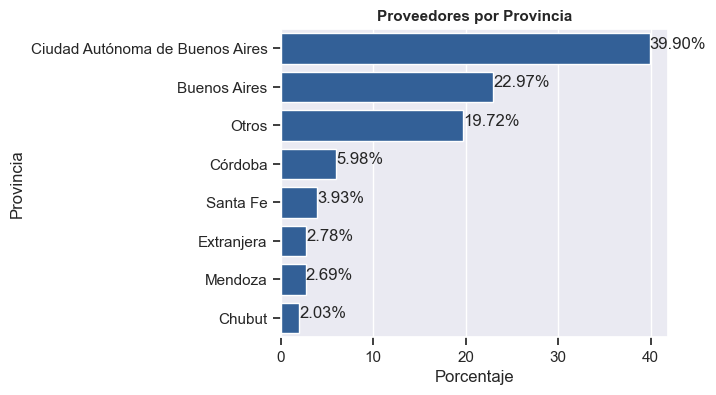

In [38]:
plt.figure(figsize=(5, 4))
sns.set_palette(paleta1)
g = sns.barplot(data=df, y='agrupador',x='percent', palette=paleta1)
g.set_title('Proveedores por Provincia', fontweight='bold',size=11)
g.set(xlabel='Porcentaje', ylabel='Provincia')

total = len(df['percent'])
for p in g.patches:
        percentage = '{:.2f}%'.format(p.get_width())
        x = p.get_x() + p.get_width() + 0.01
        y = p.get_y() + p.get_height()/2
        g.annotate(percentage, (x, y))

In [123]:
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,CorreoInstitucional,RegistroPublicoComercio,InspeccionGeneralJusticia,periodo_preinscripcion,anio_preinscripcion,nombre_proveedor,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad,provincia
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",sin datos,sin datos,sin datos,201610,2016,edit mabel RETAMAR,68.000000,8115554.160000,5.000000,Chubut
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",electricidadchiclana@e-chiclana.com.ar,sin datos,sin datos,201608,2016,Electricidad Chiclana de R. Santoianni y O.S. ...,7.000000,1776744.250000,5.000000,Ciudad Autónoma de Buenos Aires
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",LICICOM.SRL@GMAIL.COM,sin datos,53538,201609,2016,LICICOM S.R.L.,22.000000,3155202.820000,5.000000,Ciudad Autónoma de Buenos Aires
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",ylumsa@ylumsa.com.ar,3886,1718555,201608,2016,YLUM S.A.,111.000000,34954272.040000,5.000000,Ciudad Autónoma de Buenos Aires
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",info@companiadehigiene.com.ar,8196,1846001,201610,2016,COMPAÑÍA DE HIGIENE,1.000000,2557540.800000,5.000000,Buenos Aires
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",sin datos,sin datos,sin datos,202208,2022,MARIO CEFERINO LAZARTE,1.000000,7154950.000000,0.000000,Buenos Aires
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",administracion@comercialdeturismo.com,sin datos,478847,202207,2022,Hotel Astor Sociedad Anonima Comercial,1.000000,21710000.000000,0.000000,Ciudad Autónoma de Buenos Aires
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",jdiaz@hotelmadero.com,sin datos,20959,202209,2022,GIJON SA,1.000000,13830299.000000,0.000000,Ciudad Autónoma de Buenos Aires
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",info@listospararodar.com.ar,30716441098,30716441098,201908,2019,LISTOS PARA RODAR SAS,1.000000,115000.000000,2.000000,Ciudad Autónoma de Buenos Aires


#### cantidad de socios

In [145]:
socios=pd.read_csv(ruta_dataset_splitting+"datos_sociosplitting2016_2022.csv", sep='|', encoding='utf-8-sig', decimal=",", thousands='.')

In [146]:
socios['cant_socios'] = socios.groupby(['CUIT'])['doc_socio'].transform("count")

In [147]:
socios2 = socios[['CUIT','cant_socios']]
socios2 = socios2.drop_duplicates()
socios2.describe()

,cant_socios
count,6106.000000
mean,2.103177
std,1.500696
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,31.000000


In [148]:
data_proveedor3 = data_proveedor3.merge(socios2, on='CUIT', how='left')

In [149]:
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,...,RegistroPublicoComercio,InspeccionGeneralJusticia,periodo_preinscripcion,anio_preinscripcion,nombre_proveedor,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad,provincia,cant_socios
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,sin datos,sin datos,201610,2016,edit mabel RETAMAR,68.000000,10696180.940000,5.000000,Chubut,NaN
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,sin datos,sin datos,201608,2016,Electricidad Chiclana de R. Santoianni y O.S. ...,7.000000,4975161.930000,5.000000,Ciudad Autónoma de Buenos Aires,1.000000
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",...,sin datos,53538,201609,2016,LICICOM S.R.L.,22.000000,7425067.382000,5.000000,Ciudad Autónoma de Buenos Aires,2.000000
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",...,3886,1718555,201608,2016,YLUM S.A.,111.000000,59593132.970000,5.000000,Ciudad Autónoma de Buenos Aires,1.000000
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",...,8196,1846001,201610,2016,COMPAÑÍA DE HIGIENE,1.000000,5434774.200000,5.000000,Buenos Aires,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",...,sin datos,sin datos,202208,2022,MARIO CEFERINO LAZARTE,1.000000,5792102.381000,0.000000,Buenos Aires,NaN
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",...,sin datos,478847,202207,2022,Hotel Astor Sociedad Anonima Comercial,1.000000,17574761.900000,0.000000,Ciudad Autónoma de Buenos Aires,2.000000
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,sin datos,20959,202209,2022,GIJON SA,1.000000,11195956.330000,0.000000,Ciudad Autónoma de Buenos Aires,3.000000
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,30716441098,30716441098,201908,2019,LISTOS PARA RODAR SAS,1.000000,119693.877600,2.000000,Ciudad Autónoma de Buenos Aires,2.000000


#### cantidad de sanciones y apercibimientos

In [150]:

sanciones=pd.read_csv(ruta_dataset_splitting+"datos_sancionesProveedorSplitting2016_2022.csv", sep='|', encoding='utf-8-sig', decimal=",", thousands='.')

In [151]:
sanciones

,CUIT,tipo_sancion,estado,plazo,fecha_inicio,fecha_fin,encuadre_legal,observaciones,anio_inicio,periodo_inicio,anio_fin,periodo_fin
0,30711500363,Apercibimiento,Vigente,sin datos,sin datos,sin datos,Artículo 131 inciso a) apartado 1 del Anexo al...,sin datos,sin datos,sin datos,sin datos,sin datos
1,30711500363,Suspensión,Cumplida,10 días,20/4/2018,29/4/2018,Artículo 106 inciso b) apartado 1.2. del Anexo...,sin datos,2018,201804,2018,201804
2,30711500363,Suspensión,Cumplida,10 días,1/11/2018,10/11/2018,Artículo 106 inciso b) apartado 1.3. del Anexo...,sin datos,2018,201811,2018,201811
3,30590151013,Apercibimiento,Vigente,sin datos,sin datos,sin datos,Artículo 106 inciso a) apartado 2 del Anexo al...,sin datos,sin datos,sin datos,sin datos,sin datos
4,30591267759,Apercibimiento,Vigente,sin datos,sin datos,sin datos,Artículo 106 inciso a) apartado 2 del Anexo al...,sin datos,sin datos,sin datos,sin datos,sin datos
...,...,...,...,...,...,...,...,...,...,...,...,...
359,A28006104,Apercibimiento,Vigente,sin datos,sin datos,sin datos,Artículo 106 inciso a) apartado 2 del Anexo al...,Disposición Firma Conjunta N° DISFC-2021-55-AP...,sin datos,sin datos,sin datos,sin datos
360,214349010016,Apercibimiento,Vigente,sin datos,sin datos,sin datos,Artículo 106 inciso a) apartado 2 del Anexo al...,sin datos,sin datos,sin datos,sin datos,sin datos
361,30716582082,Apercibimiento,Vigente,sin datos,sin datos,sin datos,Artículo 106 inciso a) apartado 2 del Anexo al...,sin datos,sin datos,sin datos,sin datos,sin datos
362,30707835563,Suspensión,Cumplida,"4 meses,",8/10/2018,7/2/2019,Artículo 106 inciso b) apartado 1.3. del Anexo...,IMPORTANTE: Se hace saber que por conducto de ...,2018,201810,2019,201902


In [152]:
sanciones['tipo_sancion2'] = sanciones['tipo_sancion'].astype('category')

In [153]:
sanciones['tipo_sancion2'] = sanciones['tipo_sancion'].astype('category')
Apercibimiento = sanciones[sanciones['tipo_sancion']=='Apercibimiento'].groupby(['CUIT']).size().reset_index(name='count') 
Apercibimiento.rename(columns = {'count':'cant_apercibimientos'}, inplace = True)
Suspension = sanciones[sanciones['tipo_sancion']=='Suspensión'].groupby(['CUIT']).size().reset_index(name='count') 
Suspension.rename(columns = {'count':'cant_suspensiones'}, inplace = True)


In [154]:
Apercibimiento.describe()

,cant_apercibimientos
count,141.000000
mean,1.078014
std,0.294495
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000


In [155]:
Suspension.describe()

,cant_suspensiones
count,116.000000
mean,1.827586
std,1.105527
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,7.000000


In [156]:
data_proveedor3 = data_proveedor3.merge(Apercibimiento, on='CUIT', how='left')

In [157]:
data_proveedor3 = data_proveedor3.merge(Suspension, on='CUIT', how='left')

In [158]:
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,...,periodo_preinscripcion,anio_preinscripcion,nombre_proveedor,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad,provincia,cant_socios,cant_apercibimientos,cant_suspensiones
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,201610,2016,edit mabel RETAMAR,68.000000,10696180.940000,5.000000,Chubut,NaN,NaN,NaN
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,201608,2016,Electricidad Chiclana de R. Santoianni y O.S. ...,7.000000,4975161.930000,5.000000,Ciudad Autónoma de Buenos Aires,1.000000,NaN,NaN
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",...,201609,2016,LICICOM S.R.L.,22.000000,7425067.382000,5.000000,Ciudad Autónoma de Buenos Aires,2.000000,1.000000,2.000000
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",...,201608,2016,YLUM S.A.,111.000000,59593132.970000,5.000000,Ciudad Autónoma de Buenos Aires,1.000000,NaN,NaN
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",...,201610,2016,COMPAÑÍA DE HIGIENE,1.000000,5434774.200000,5.000000,Buenos Aires,2.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",...,202208,2022,MARIO CEFERINO LAZARTE,1.000000,5792102.381000,0.000000,Buenos Aires,NaN,NaN,NaN
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",...,202207,2022,Hotel Astor Sociedad Anonima Comercial,1.000000,17574761.900000,0.000000,Ciudad Autónoma de Buenos Aires,2.000000,NaN,NaN
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,202209,2022,GIJON SA,1.000000,11195956.330000,0.000000,Ciudad Autónoma de Buenos Aires,3.000000,NaN,NaN
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,201908,2019,LISTOS PARA RODAR SAS,1.000000,119693.877600,2.000000,Ciudad Autónoma de Buenos Aires,2.000000,NaN,NaN


#### cantidad de antecedentes

In [159]:

antecedentes=pd.read_csv(ruta_dataset_splitting+"datos_antecedentesProveedorSplitting2016_2022.csv", sep='|', encoding='utf-8-sig', decimal=",", thousands='.')


In [160]:
antecedentes['cant_antecedentes'] = antecedentes.groupby(['CUIT'])['CUIT'].transform("count")
antecedentes2 = antecedentes[['CUIT','cant_antecedentes']]


In [161]:
antecedentes2.describe()

,cant_antecedentes
count,392.000000
mean,2.494898
std,1.706007
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,8.000000


In [162]:
antecedentes2 = antecedentes2.drop_duplicates()
data_proveedor3 = data_proveedor3.merge(antecedentes2, on='CUIT', how='left')

In [163]:
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,...,anio_preinscripcion,nombre_proveedor,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad,provincia,cant_socios,cant_apercibimientos,cant_suspensiones,cant_antecedentes
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,2016,edit mabel RETAMAR,68.000000,10696180.940000,5.000000,Chubut,NaN,NaN,NaN,NaN
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,2016,Electricidad Chiclana de R. Santoianni y O.S. ...,7.000000,4975161.930000,5.000000,Ciudad Autónoma de Buenos Aires,1.000000,NaN,NaN,NaN
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",...,2016,LICICOM S.R.L.,22.000000,7425067.382000,5.000000,Ciudad Autónoma de Buenos Aires,2.000000,1.000000,2.000000,4.000000
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",...,2016,YLUM S.A.,111.000000,59593132.970000,5.000000,Ciudad Autónoma de Buenos Aires,1.000000,NaN,NaN,NaN
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",...,2016,COMPAÑÍA DE HIGIENE,1.000000,5434774.200000,5.000000,Buenos Aires,2.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",...,2022,MARIO CEFERINO LAZARTE,1.000000,5792102.381000,0.000000,Buenos Aires,NaN,NaN,NaN,NaN
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",...,2022,Hotel Astor Sociedad Anonima Comercial,1.000000,17574761.900000,0.000000,Ciudad Autónoma de Buenos Aires,2.000000,NaN,NaN,NaN
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,2022,GIJON SA,1.000000,11195956.330000,0.000000,Ciudad Autónoma de Buenos Aires,3.000000,NaN,NaN,NaN
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,2019,LISTOS PARA RODAR SAS,1.000000,119693.877600,2.000000,Ciudad Autónoma de Buenos Aires,2.000000,NaN,NaN,NaN


#### cantidad de representantes

In [164]:

representantes=pd.read_csv(ruta_dataset_splitting+"data_apoderadosSplitting2016_2022.csv", sep='|', encoding='utf-8-sig', decimal=",", thousands='.')
representantes

,CUIT,nombre_apellido,cuit_apoderado,dni,tipo_representacion,monto_lim_oferta,adm_legitimado,pos,tipo_documento,nro_documento
0,27236909900,edit mabel RETAMAR,27-23690990-0,DNI 23690990,Apoderado,Sin límite,Autenticado,3,DNI,23690990
1,30569211685,Oscar Segundo Rodriguez,20-08309191-7,DNI 8309191,Apoderado,Sin límite,Autenticado,3,DNI,8309191
2,30711500363,DANIEL MARIO LEBENSOHN,20-13565807-4,DNI 13565807,Apoderado,Sin límite,No autenticado,3,DNI,13565807
3,30711500363,AGUSTIN LEBENSOHN,20-34870888-1,DNI 34870888,Apoderado,Sin límite,Autenticado,3,DNI,34870888
4,30711500363,JULIAN LEBENSOHN,20-32437201-7,DNI 32437201,Representante Legal,Sin límite,Autenticado,3,DNI,32437201
...,...,...,...,...,...,...,...,...,...,...
13524,30518773743,Hernan Eduardo Leira,20-12767215-7,DNI 12767215,Apoderado,Sin límite,No autenticado,3,DNI,12767215
13525,30518773743,Silvia Beatriz Leiva,23-11874364-4,DNI 11874364,Representante Legal,Sin límite,Autenticado,3,DNI,11874364
13526,30700503891,GUSTAVO ADRIAN ESAIN,20-28165401-3,DNI 28165401,Apoderado,"29000000,00",Autenticado,3,DNI,28165401
13527,30716441098,LUCAS EDGRADO MATIAS SCHIAFFINO BENITEZ,20-32571041-2,DNI 32571041,Apoderado,Sin límite,Autenticado,3,DNI,32571041


In [165]:
representantes['tipo_representacion2'] = representantes['tipo_representacion'].astype('category')

In [166]:
Apoderado = representantes[representantes['tipo_representacion']=='Apoderado'].groupby(['CUIT']).size().reset_index(name='count') 
Apoderado.rename(columns = {'count':'cant_Apoderado'}, inplace = True)
representante = representantes[representantes['tipo_representacion']=='Representante Legal'].groupby(['CUIT']).size().reset_index(name='count') 
#sanciones.groupby(['CUIT'])['tipo_sancion'].apply(lambda x: (x=='Apercibimiento').sum()).reset_index(name='count')
representante.rename(columns = {'count':'cant_representante'}, inplace = True)

In [167]:
Apoderado=Apoderado.drop_duplicates()
Apoderado.describe()


,cant_Apoderado
count,7471.000000
mean,1.218043
std,0.661001
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,12.000000


In [168]:
representante.describe()

,cant_representante
count,3959.000000
mean,1.118464
std,0.403196
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,10.000000


In [169]:
data_proveedor3 = data_proveedor3.merge(Apoderado, on='CUIT', how='left')
data_proveedor3 = data_proveedor3.merge(representante, on='CUIT', how='left')

In [170]:
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,...,cant_procesos_adjudicado,monto_total_adjudicado,antiguedad,provincia,cant_socios,cant_apercibimientos,cant_suspensiones,cant_antecedentes,cant_Apoderado,cant_representante
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,68.000000,10696180.940000,5.000000,Chubut,NaN,NaN,NaN,NaN,1.000000,NaN
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,7.000000,4975161.930000,5.000000,Ciudad Autónoma de Buenos Aires,1.000000,NaN,NaN,NaN,1.000000,NaN
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",...,22.000000,7425067.382000,5.000000,Ciudad Autónoma de Buenos Aires,2.000000,1.000000,2.000000,4.000000,2.000000,1.000000
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",...,111.000000,59593132.970000,5.000000,Ciudad Autónoma de Buenos Aires,1.000000,NaN,NaN,NaN,1.000000,NaN
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",...,1.000000,5434774.200000,5.000000,Buenos Aires,2.000000,NaN,NaN,NaN,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",...,1.000000,5792102.381000,0.000000,Buenos Aires,NaN,NaN,NaN,NaN,1.000000,NaN
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",...,1.000000,17574761.900000,0.000000,Ciudad Autónoma de Buenos Aires,2.000000,NaN,NaN,NaN,1.000000,1.000000
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,1.000000,11195956.330000,0.000000,Ciudad Autónoma de Buenos Aires,3.000000,NaN,NaN,NaN,1.000000,NaN
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,1.000000,119693.877600,2.000000,Ciudad Autónoma de Buenos Aires,2.000000,NaN,NaN,NaN,1.000000,NaN


#### cantidad de administradores legitimados

In [ ]:
representantes['adm_legitimado2'] = representantes['adm_legitimado'].astype('category')

autenticado = representantes[representantes['adm_legitimado']=='Autenticado'].groupby(['CUIT']).size().reset_index(name='count') 
autenticado.rename(columns = {'count':'cant_autenticado'}, inplace = True)
noAutenticado = representantes[representantes['adm_legitimado']=='No autenticado'].groupby(['CUIT']).size().reset_index(name='count') 
#sanciones.groupby(['CUIT'])['tipo_sancion'].apply(lambda x: (x=='Apercibimiento').sum()).reset_index(name='count')
noAutenticado.rename(columns = {'count':'cant_noAutenticado'}, inplace = True)

In [172]:
autenticado.describe()

,cant_autenticado
count,9975.000000
mean,1.196291
std,0.529240
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,11.000000


In [173]:
noAutenticado.describe()

,cant_noAutenticado
count,1176.000000
mean,1.356293
std,0.927001
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,12.000000


In [174]:
data_proveedor3 = data_proveedor3.merge(autenticado, on='CUIT', how='left')
data_proveedor3 = data_proveedor3.merge(noAutenticado, on='CUIT', how='left')

In [175]:
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,...,antiguedad,provincia,cant_socios,cant_apercibimientos,cant_suspensiones,cant_antecedentes,cant_Apoderado,cant_representante,cant_autenticado,cant_noAutenticado
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,5.000000,Chubut,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,5.000000,Ciudad Autónoma de Buenos Aires,1.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",...,5.000000,Ciudad Autónoma de Buenos Aires,2.000000,1.000000,2.000000,4.000000,2.000000,1.000000,2.000000,1.000000
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",...,5.000000,Ciudad Autónoma de Buenos Aires,1.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",...,5.000000,Buenos Aires,2.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",...,0.000000,Buenos Aires,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",...,0.000000,Ciudad Autónoma de Buenos Aires,2.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,0.000000,Ciudad Autónoma de Buenos Aires,3.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,2.000000,Ciudad Autónoma de Buenos Aires,2.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN


#### monto limite de oferta

In [176]:
#Límite de ofertas para apoderados

sin_monto = representantes[representantes['monto_lim_oferta']=='Sin límite'].groupby(['CUIT']).size().reset_index(name='count') 
sin_monto.rename(columns = {'count':'cant_sinMontoLimite'}, inplace = True)
monto = representantes[representantes['monto_lim_oferta']!='Sin límite'].groupby(['CUIT']).size().reset_index(name='count') 
#sanciones.groupby(['CUIT'])['tipo_sancion'].apply(lambda x: (x=='Apercibimiento').sum()).reset_index(name='count')
monto.rename(columns = {'count':'cant_MontoLimite'}, inplace = True)

In [177]:
sin_monto.describe()

,cant_sinMontoLimite
count,9891.000000
mean,1.347285
std,0.759575
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,13.000000


In [178]:
monto.describe()

,cant_MontoLimite
count,162.000000
mean,1.253086
std,0.623671
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,6.000000


In [179]:
data_proveedor3 = data_proveedor3.merge(sin_monto, on='CUIT', how='left')
data_proveedor3 = data_proveedor3.merge(monto, on='CUIT', how='left')

In [180]:
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,...,cant_socios,cant_apercibimientos,cant_suspensiones,cant_antecedentes,cant_Apoderado,cant_representante,cant_autenticado,cant_noAutenticado,cant_sinMontoLimite,cant_MontoLimite
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,1.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",...,2.000000,1.000000,2.000000,4.000000,2.000000,1.000000,2.000000,1.000000,3.000000,NaN
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",...,1.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",...,2.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,1.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",...,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",...,2.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,2.000000,NaN
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,3.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,1.000000
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,2.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,1.000000,NaN


#### cant Artículos que provee por Clase

In [ ]:
articulos=pd.read_csv(ruta_dataset_splitting+"datos_Proveedor_clasesSplitting2016_2022.csv", sep='|', encoding='utf-8-sig', decimal=",", thousands='.')

In [182]:
articulos

,CUIT,Nro_clases,codigo_clase,descripcion_clase,codigo_rubro,descripcion_rubro
0,27236909900,68,9.281,BASES TOMACORRIENTE,90,ELECTRICIDAD Y TELEFONIA
1,27236909900,68,9.1766,PROLONGADOR DE ELECTRICIDAD,90,ELECTRICIDAD Y TELEFONIA
2,27236909900,68,14.401,CARTUCHOS DE TONER,140,REPUESTOS
3,27236909900,68,9.2159,REFLECTOR,90,ELECTRICIDAD Y TELEFONIA
4,27236909900,68,9.2092,ARTEF.P/TUBO FLUORESCENTE,90,ELECTRICIDAD Y TELEFONIA
...,...,...,...,...,...,...
699686,30716441098,19,589884,SERVICIO DE LOCUCION,580,SERV. PROFESIONAL Y COMERCIAL
699687,27331126530,4,362185,SERVICIO DE AUDIOVISUALES,360,CINE/TELVIS./RADIO/FOTOGRAFIA
699688,27331126530,4,362179,PELICULAS P/FILMACION,360,CINE/TELVIS./RADIO/FOTOGRAFIA
699689,27331126530,4,363029,PELICULAS EN VIDEO,360,CINE/TELVIS./RADIO/FOTOGRAFIA


In [183]:
#agrupa por rubro
articulos['total_rubro'] = articulos.groupby(['CUIT','descripcion_rubro'])['descripcion_rubro'].transform("count")


In [184]:
#crear variable total Bienes y Total para servicios
articulos['TOT_AGROPECUARIO'] = np.where(articulos['descripcion_rubro']== 'AGRIC,GANADERIA,CAZA,SILVICULT',articulos["total_rubro"] ,0)
articulos['TOT_ALIMENTOS'] = np.where(articulos['descripcion_rubro']== 'ALIMENTOS',articulos["total_rubro"] ,0)
articulos['TOT_ALQUILER'] = np.where(articulos['descripcion_rubro']== 'ALQUILER',articulos["total_rubro"] ,0)
articulos['TOT_ART_HOGAR'] = np.where(articulos['descripcion_rubro']== 'ARTICULOS DEL HOGAR',articulos["total_rubro"] ,0)
articulos['TOT_BANCO'] = np.where(articulos['descripcion_rubro']== 'BANCOS Y SEGUROS',articulos["total_rubro"] ,0)
articulos['TOT_BAZAR'] = np.where(articulos['descripcion_rubro']== 'BAZAR Y MENAJE',articulos["total_rubro"] ,0)
articulos['TOT_CARPINTERIA'] = np.where(articulos['descripcion_rubro']== 'CARPINTERIA',articulos["total_rubro"] ,0)
articulos['TOT_CEREMONIAL'] = np.where(articulos['descripcion_rubro']== 'CEREMONIAL',articulos["total_rubro"] ,0)
articulos['TOT_CERRAJERIA'] = np.where(articulos['descripcion_rubro']== 'CERRAJERIA',articulos["total_rubro"] ,0)
articulos['TOT_CINE'] = np.where(articulos['descripcion_rubro']== 'CINE/TELVIS./RADIO/FOTOGRAFIA',articulos["total_rubro"] ,0)
articulos['TOT_COMBUSTIBLES'] = np.where(articulos['descripcion_rubro']== 'COMBUSTIBLES Y LUBRICANTES',articulos["total_rubro"] ,0)
articulos['TOT_CONCESION'] = np.where(articulos['descripcion_rubro']== 'CONCESION',articulos["total_rubro"] ,0)
articulos['TOT_CONSTRUCCION'] = np.where(articulos['descripcion_rubro']== 'CONSTRUCCION',articulos["total_rubro"] ,0)
articulos['TOT_CULTURA'] = np.where(articulos['descripcion_rubro']== 'CULTURA',articulos["total_rubro"] ,0)
articulos['TOT_ELECTRICIDAD'] = np.where(articulos['descripcion_rubro']== 'ELECTRICIDAD Y TELEFONIA',articulos["total_rubro"] ,0)
articulos['TOT_LIMPIEZA'] = np.where(articulos['descripcion_rubro']== 'ELEMENTOS DE LIMPIEZA',articulos["total_rubro"] ,0)
articulos['TOT_MUEBLES'] = np.where(articulos['descripcion_rubro']== 'EQUIPO DE OFICINA Y MUEBLES',articulos["total_rubro"] ,0)
articulos['TOT_EQUIPO_MILITAR'] = np.where(articulos['descripcion_rubro']== 'EQUIPO MILITAR Y DE SEGURIDAD',articulos["total_rubro"] ,0)
articulos['TOT_EQUIPOS'] = np.where(articulos['descripcion_rubro']== 'EQUIPOS',articulos["total_rubro"] ,0)
articulos['TOT_FERRETERIA'] = np.where(articulos['descripcion_rubro']== 'FERRETERIA',articulos["total_rubro"] ,0)
articulos['TOT_GASES_IND'] = np.where(articulos['descripcion_rubro']== 'GASES INDUSTRIALES',articulos["total_rubro"] ,0)
articulos['TOT_HERRAMIENTAS'] = np.where(articulos['descripcion_rubro']== 'HERRAMIENTAS',articulos["total_rubro"] ,0)
articulos['TOT_HERRERIA'] = np.where(articulos['descripcion_rubro']== 'HERRERIA',articulos["total_rubro"] ,0)
articulos['TOT_IMPRENTA'] = np.where(articulos['descripcion_rubro']== 'IMPRENTA Y EDITORIALES',articulos["total_rubro"] ,0)
articulos['TOT_INDUMENTARIA'] = np.where(articulos['descripcion_rubro']== 'INDUMENT TEXTIL Y CONFECCIONES',articulos["total_rubro"] ,0)
articulos['TOT_INFORMATICA'] = np.where(articulos['descripcion_rubro']== 'INFORMATICA',articulos["total_rubro"] ,0)
articulos['TOT_INMUEBLES'] = np.where(articulos['descripcion_rubro']== 'INMUEBLES',articulos["total_rubro"] ,0)
articulos['TOT_INSUMO_ARMAMENTO'] = np.where(articulos['descripcion_rubro']== 'INSUMO P/ ARMAMENTO',articulos["total_rubro"] ,0)
articulos['TOT_JOYERIA'] = np.where(articulos['descripcion_rubro']== 'JOYERIA Y ORFEBRERIA',articulos["total_rubro"] ,0)
articulos['TOT_LIBRERIA'] = np.where(articulos['descripcion_rubro']== 'LIBRERIA,PAP. Y UTILES OFICINA',articulos["total_rubro"] ,0)
articulos['TOT_MANTENIMIENTO'] = np.where(articulos['descripcion_rubro']== 'MANT. REPARACION Y LIMPIEZA',articulos["total_rubro"] ,0)
articulos['TOT_METALES'] = np.where(articulos['descripcion_rubro']== 'METALES',articulos["total_rubro"] ,0)
articulos['TOT_METALURGIA'] = np.where(articulos['descripcion_rubro']== 'METALURGIA',articulos["total_rubro"] ,0)
articulos['TOT_CONSTRUCCION'] = np.where(articulos['descripcion_rubro']== 'MATERIALES DE CONSTRUCCION',articulos["total_rubro"] ,0)
articulos['TOT_NAUTICA'] = np.where(articulos['descripcion_rubro']== 'NAUTICA',articulos["total_rubro"] ,0)
articulos['TOT_PINTURAS'] = np.where(articulos['descripcion_rubro']== 'PINTURAS',articulos["total_rubro"] ,0)
articulos['TOT_PROD_MEDICOS'] = np.where(articulos['descripcion_rubro']== 'PROD. MEDICO/FARMACEUTICOS/LAB',articulos["total_rubro"] ,0)
articulos['TOT_PROD_VETERINARIOS'] = np.where(articulos['descripcion_rubro']== 'PRODUCTOS VETERINARIOS',articulos["total_rubro"] ,0)
articulos['TOT_QUIMICOS'] = np.where(articulos['descripcion_rubro']== 'QUIMICOS',articulos["total_rubro"] ,0)
articulos['TOT_REPUESTOS'] = np.where(articulos['descripcion_rubro']== 'REPUESTOS',articulos["total_rubro"] ,0)
articulos['TOT_PLOMERIA'] = np.where(articulos['descripcion_rubro']== 'SANITARIOS, PLOMERIA Y GAS',articulos["total_rubro"] ,0)
articulos['TOT_SERV_PROFESIONAL'] = np.where(articulos['descripcion_rubro']== 'SERV. PROFESIONAL Y COMERCIAL',articulos["total_rubro"] ,0)
articulos['TOT_SERV_NOTICIAS'] = np.where(articulos['descripcion_rubro']== 'SERVICIO DE NOTICIAS',articulos["total_rubro"] ,0)
articulos['TOT_SERV_BASICOS'] = np.where(articulos['descripcion_rubro']== 'SERVICIOS BASICOS',articulos["total_rubro"] ,0)
articulos['TOT_TAPICERIA'] = np.where(articulos['descripcion_rubro']== 'TAPICERIA',articulos["total_rubro"] ,0)
articulos['TOT_TRANSPORTE'] = np.where(articulos['descripcion_rubro']== 'TRANSPORTE Y DEPOSITO',articulos["total_rubro"] ,0)
articulos['TOT_PROD_DEPORTIVOS'] = np.where(articulos['descripcion_rubro']== 'UTILES Y PRODUCTOS DEPORTIVOS',articulos["total_rubro"] ,0)
articulos['TOT_VIDRIERIA'] = np.where(articulos['descripcion_rubro']== 'VIDRIERIA',articulos["total_rubro"] ,0)
articulos['TOT_VIGILANCIA'] = np.where(articulos['descripcion_rubro']== 'VIGILANCIA Y SEGURIDAD',articulos["total_rubro"] ,0)

#reducir items para obtener para cada proceso la info relativa a los rubros que solicita comprar

proveedor_item = articulos[['CUIT','TOT_AGROPECUARIO', 'TOT_ALIMENTOS','TOT_ALQUILER','TOT_ART_HOGAR','TOT_BANCO','TOT_BAZAR','TOT_CARPINTERIA','TOT_CEREMONIAL','TOT_CERRAJERIA','TOT_CINE','TOT_COMBUSTIBLES','TOT_CONCESION','TOT_CONSTRUCCION','TOT_CULTURA','TOT_ELECTRICIDAD','TOT_LIMPIEZA','TOT_MUEBLES','TOT_EQUIPO_MILITAR','TOT_EQUIPOS','TOT_FERRETERIA','TOT_GASES_IND','TOT_HERRAMIENTAS','TOT_HERRERIA','TOT_IMPRENTA','TOT_INDUMENTARIA','TOT_INFORMATICA','TOT_INMUEBLES','TOT_INSUMO_ARMAMENTO','TOT_JOYERIA','TOT_LIBRERIA','TOT_MANTENIMIENTO','TOT_METALES','TOT_METALURGIA','TOT_CONSTRUCCION','TOT_NAUTICA','TOT_PINTURAS','TOT_PROD_MEDICOS','TOT_PROD_VETERINARIOS','TOT_QUIMICOS','TOT_REPUESTOS','TOT_PLOMERIA','TOT_SERV_PROFESIONAL','TOT_SERV_NOTICIAS','TOT_SERV_BASICOS','TOT_TAPICERIA','TOT_TRANSPORTE','TOT_PROD_DEPORTIVOS','TOT_VIDRIERIA','TOT_VIGILANCIA']]

#quitar duplicados
proveedor_item = proveedor_item.drop_duplicates()


In [185]:
#unificar totales en una sola fila para el caso de que un mismo proceso tenga distintos rubros 

proveedor_item["TOT_AGROPECUARIO"] = proveedor_item.groupby(["CUIT"])["TOT_AGROPECUARIO"].transform("sum")
proveedor_item["TOT_ALIMENTOS"] = proveedor_item.groupby(["CUIT"])["TOT_ALIMENTOS"].transform("sum")
proveedor_item["TOT_ALQUILER"] = proveedor_item.groupby(["CUIT"])["TOT_ALQUILER"].transform("sum")
proveedor_item["TOT_ART_HOGAR"] = proveedor_item.groupby(["CUIT"])["TOT_ART_HOGAR"].transform("sum")
proveedor_item["TOT_BANCO"] = proveedor_item.groupby(["CUIT"])["TOT_BANCO"].transform("sum")
proveedor_item["TOT_BAZAR"] = proveedor_item.groupby(["CUIT"])["TOT_BAZAR"].transform("sum")
proveedor_item["TOT_CARPINTERIA"] = proveedor_item.groupby(["CUIT"])["TOT_CARPINTERIA"].transform("sum")
proveedor_item["TOT_CEREMONIAL"] = proveedor_item.groupby(["CUIT"])["TOT_CEREMONIAL"].transform("sum")
proveedor_item["TOT_CERRAJERIA"] = proveedor_item.groupby(["CUIT"])["TOT_CERRAJERIA"].transform("sum")
proveedor_item["TOT_CINE"] = proveedor_item.groupby(["CUIT"])["TOT_CINE"].transform("sum")
proveedor_item["TOT_COMBUSTIBLES"] = proveedor_item.groupby(["CUIT"])["TOT_COMBUSTIBLES"].transform("sum")
proveedor_item["TOT_CONCESION"] = proveedor_item.groupby(["CUIT"])["TOT_CONCESION"].transform("sum")
proveedor_item["TOT_CONSTRUCCION"] = proveedor_item.groupby(["CUIT"])["TOT_CONSTRUCCION"].transform("sum")
proveedor_item["TOT_CULTURA"] = proveedor_item.groupby(["CUIT"])["TOT_CULTURA"].transform("sum")
proveedor_item["TOT_ELECTRICIDAD"] = proveedor_item.groupby(["CUIT"])["TOT_ELECTRICIDAD"].transform("sum")
proveedor_item["TOT_LIMPIEZA"] = proveedor_item.groupby(["CUIT"])["TOT_LIMPIEZA"].transform("sum")
proveedor_item["TOT_MUEBLES"] = proveedor_item.groupby(["CUIT"])["TOT_MUEBLES"].transform("sum")
proveedor_item["TOT_EQUIPO_MILITAR"] = proveedor_item.groupby(["CUIT"])["TOT_EQUIPO_MILITAR"].transform("sum")
proveedor_item["TOT_EQUIPOS"] = proveedor_item.groupby(["CUIT"])["TOT_EQUIPOS"].transform("sum")
proveedor_item["TOT_FERRETERIA"] = proveedor_item.groupby(["CUIT"])["TOT_FERRETERIA"].transform("sum")
proveedor_item["TOT_GASES_IND"] = proveedor_item.groupby(["CUIT"])["TOT_GASES_IND"].transform("sum")
proveedor_item["TOT_HERRAMIENTAS"] = proveedor_item.groupby(["CUIT"])["TOT_HERRAMIENTAS"].transform("sum")
proveedor_item["TOT_HERRERIA"] = proveedor_item.groupby(["CUIT"])["TOT_HERRERIA"].transform("sum")
proveedor_item["TOT_IMPRENTA"] = proveedor_item.groupby(["CUIT"])["TOT_IMPRENTA"].transform("sum")
proveedor_item["TOT_INDUMENTARIA"] = proveedor_item.groupby(["CUIT"])["TOT_INDUMENTARIA"].transform("sum")
proveedor_item["TOT_INFORMATICA"] = proveedor_item.groupby(["CUIT"])["TOT_INFORMATICA"].transform("sum")
proveedor_item["TOT_INMUEBLES"] = proveedor_item.groupby(["CUIT"])["TOT_INMUEBLES"].transform("sum")
proveedor_item["TOT_INSUMO_ARMAMENTO"] = proveedor_item.groupby(["CUIT"])["TOT_INSUMO_ARMAMENTO"].transform("sum")
proveedor_item["TOT_JOYERIA"] = proveedor_item.groupby(["CUIT"])["TOT_JOYERIA"].transform("sum")
proveedor_item["TOT_LIBRERIA"] = proveedor_item.groupby(["CUIT"])["TOT_LIBRERIA"].transform("sum")
proveedor_item["TOT_MANTENIMIENTO"] = proveedor_item.groupby(["CUIT"])["TOT_MANTENIMIENTO"].transform("sum")
proveedor_item["TOT_METALES"] = proveedor_item.groupby(["CUIT"])["TOT_METALES"].transform("sum")
proveedor_item["TOT_METALURGIA"] = proveedor_item.groupby(["CUIT"])["TOT_METALURGIA"].transform("sum")
proveedor_item["TOT_CONSTRUCCION"] = proveedor_item.groupby(["CUIT"])["TOT_CONSTRUCCION"].transform("sum")
proveedor_item["TOT_NAUTICA"] = proveedor_item.groupby(["CUIT"])["TOT_NAUTICA"].transform("sum")
proveedor_item["TOT_PINTURAS"] = proveedor_item.groupby(["CUIT"])["TOT_PINTURAS"].transform("sum")
proveedor_item["TOT_PROD_MEDICOS"] = proveedor_item.groupby(["CUIT"])["TOT_PROD_MEDICOS"].transform("sum")
proveedor_item["TOT_PROD_VETERINARIOS"] = proveedor_item.groupby(["CUIT"])["TOT_PROD_VETERINARIOS"].transform("sum")
proveedor_item["TOT_QUIMICOS"] = proveedor_item.groupby(["CUIT"])["TOT_QUIMICOS"].transform("sum")
proveedor_item["TOT_REPUESTOS"] = proveedor_item.groupby(["CUIT"])["TOT_REPUESTOS"].transform("sum")
proveedor_item["TOT_PLOMERIA"] = proveedor_item.groupby(["CUIT"])["TOT_PLOMERIA"].transform("sum")
proveedor_item["TOT_SERV_PROFESIONAL"] = proveedor_item.groupby(["CUIT"])["TOT_SERV_PROFESIONAL"].transform("sum")
proveedor_item["TOT_SERV_NOTICIAS"] = proveedor_item.groupby(["CUIT"])["TOT_SERV_NOTICIAS"].transform("sum")
proveedor_item["TOT_SERV_BASICOS"] = proveedor_item.groupby(["CUIT"])["TOT_SERV_BASICOS"].transform("sum")
proveedor_item["TOT_TAPICERIA"] = proveedor_item.groupby(["CUIT"])["TOT_TAPICERIA"].transform("sum")
proveedor_item["TOT_TRANSPORTE"] = proveedor_item.groupby(["CUIT"])["TOT_TRANSPORTE"].transform("sum")
proveedor_item["TOT_PROD_DEPORTIVOS"] = proveedor_item.groupby(["CUIT"])["TOT_PROD_DEPORTIVOS"].transform("sum")
proveedor_item["TOT_VIDRIERIA"] = proveedor_item.groupby(["CUIT"])["TOT_VIDRIERIA"].transform("sum")
proveedor_item["TOT_VIGILANCIA"] = proveedor_item.groupby(["CUIT"])["TOT_VIGILANCIA"].transform("sum")


#quitar duplicados
proveedor_item = proveedor_item.drop_duplicates()


In [186]:
articulos2 = articulos[['CUIT', 'descripcion_rubro','total_rubro']]
articulos2 = articulos2.drop_duplicates()
df3 = articulos2.groupby(['descripcion_rubro'])['total_rubro'].sum()#f'{result:.9f}'
pd.options.display.float_format = '{:.0f}'.format
df3

descripcion_rubro
AGRIC,GANADERIA,CAZA,SILVICULT      718
ALIMENTOS                         29382
ALQUILER                           3199
ARTICULOS DEL HOGAR                6129
BANCOS Y SEGUROS                    493
BAZAR Y MENAJE                    14690
CARPINTERIA                        3080
CEREMONIAL                          663
CERRAJERIA                         1644
CINE/TELVIS./RADIO/FOTOGRAFIA      1299
COMBUSTIBLES Y LUBRICANTES         2379
CONCESION                            99
CONSTRUCCION                      12486
CULTURA                             429
ELECTRICIDAD Y TELEFONIA          67654
ELEMENTOS DE LIMPIEZA             18636
EQUIPO DE OFICINA Y MUEBLES       19093
EQUIPO MILITAR Y DE SEGURIDAD      2493
EQUIPOS                           57492
FERRETERIA                        73313
GASES INDUSTRIALES                   35
HERRAMIENTAS                      29395
HERRERIA                           1532
IMPRENTA Y EDITORIALES             5439
INDUMENT TEXTIL Y CONF

In [187]:
data_proveedor3 = data_proveedor3.merge(proveedor_item, on='CUIT', how='left')
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,...,TOT_REPUESTOS,TOT_PLOMERIA,TOT_SERV_PROFESIONAL,TOT_SERV_NOTICIAS,TOT_SERV_BASICOS,TOT_TAPICERIA,TOT_TRANSPORTE,TOT_PROD_DEPORTIVOS,TOT_VIDRIERIA,TOT_VIGILANCIA
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,3,14,0,0,0,0,0,0,0,0
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,0,0,0,0,0,0,0,0,0,0
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",...,1,63,1,0,0,0,0,1,0,0
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",...,4,0,0,0,0,0,0,0,0,0
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",...,0,0,0,0,0,0,1,0,0,0
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",...,0,0,5,0,0,0,0,0,0,0
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,0,0,1,0,0,0,0,0,0,0
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,0,0,11,0,0,0,0,0,0,0


#### Total de artículos provistos por proveedor

In [188]:
#agregar total por proveedor

articulos['total_articulos_provee'] = articulos.groupby(['CUIT'])['descripcion_rubro'].transform("count")
art = articulos[['CUIT','total_articulos_provee']]
art = art.drop_duplicates()
data_proveedor3 = data_proveedor3.merge(art, on='CUIT', how='left')

In [189]:
art.describe()

,total_articulos_provee
count,9977
mean,70
std,243
min,1
25%,2
50%,8
75%,40
max,6993


In [190]:
articulos.to_csv( "C:/Users/Vanina/Documents/tesis/Datos/unificados/dataset finales/feature_creation/articulos.csv", sep='|',index=False, encoding='utf-8-sig')


In [191]:
data_proveedor3.to_csv( "C:/Users/Vanina/Documents/tesis/Datos/unificados/dataset finales/feature_creation/proveedores2016_2022_nuevas_var2.csv", sep='|',index=False, encoding='utf-8-sig')


In [192]:
data_proveedor3

,CUIT,Nombre,FechaPreinscripcion,Estado,TelefonicoContacto,Constitucion,TipoSocietario,NumeroEnte,DomicilioLegal,DomicilioEspecial,...,TOT_PLOMERIA,TOT_SERV_PROFESIONAL,TOT_SERV_NOTICIAS,TOT_SERV_BASICOS,TOT_TAPICERIA,TOT_TRANSPORTE,TOT_PROD_DEPORTIVOS,TOT_VIDRIERIA,TOT_VIGILANCIA,total_articulos_provee
0,27236909900,EMR VENTAS & SERVICIOS,04/10/2016,Inscripto,2804357488,sin datos,Persona Física,4335080,"CACIQUE FRANCISCO 1398, localidad TRELEW, depa...","CACIQUE FRANCISCO 1398, localidad TRELEW, depa...",...,14,0,0,0,0,0,0,0,0,68
1,30569211685,Electricidad Chiclana de R. Santoianni y O.S. ...,18/08/2016,Desactualizado Por Documentos Vencidos,54114923-4922,En C.A.B.A. con fecha 28/05/1980,Sociedades De Hecho,36170,"Av. Boedo 1986, piso N° P.B., localidad Ciudad...","Av. Boedo 1986, piso N° P.B., localidad Ciudad...",...,0,0,0,0,0,0,0,0,0,330
2,30711500363,LICICOM S.R.L.,15/09/2016,Inscripto,45833433,"En JUAN B JUSTO Nº 925, LANUS, PROV DE BS AS c...",Sociedad Responsabilidad Limitada,3893780,"AV CORRIENTES 4709, piso N° 3, depto N° 36, lo...","SAN BLAS 2257, piso N° PB, depto N° PB, locali...",...,63,1,0,0,0,0,1,0,0,105
3,30708415487,YLUM S.A.,24/08/2016,Inscripto,541149116641,"En Rodriguez Peña 694 5º D, CABA con fecha 28/...",Sociedad Anónima,2141900,"Rodriguez Peña 694, localidad Ciudad Autónoma ...","Famatina 3933, localidad Ciudad Autónoma de Bu...",...,0,0,0,0,0,0,0,0,0,83
4,33712286089,COMPAÑÍA DE HIGIENE,26/10/2016,Inscripto,541147901907,En BUENOS AIRES con fecha 08/07/2011,Sociedad Responsabilidad Limitada,4715650,"O'Higgins 3550, localidad OLIVOS, departamento...","Obispo San Alberto 2975, localidad Ciudad Autó...",...,0,0,0,0,0,0,0,0,0,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10071,20287286687,LAZARTE MARIO,03/08/2022,Inscripto,2235465989,sin datos,Persona Física,33330,"CARAZA 3530, localidad MAR DEL PLATA, departam...","CARAZA 3530, localidad MAR DEL PLATA, departam...",...,0,0,0,0,0,1,0,0,0,1
10072,30518773743,Hotel Astor Sociedad Anonima Comercial,25/07/2022,Inscripto,541143222400,En Tigre con fecha 09/12/1968,Sociedad Anónima,16220,"Azcuenaga 1721, piso N° 6, depto N° G, localid...","Entre Rios 1649, localidad MAR DEL PLATA, depa...",...,0,5,0,0,0,0,0,0,0,6
10073,30700503891,GIJON SA,07/09/2022,Inscripto,1160190901,En CABA con fecha 23/07/1998,Sociedad Anónima,18500,"VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...","VERA PEÑALOZA,ROSARIO BOULEVARD 360, localidad...",...,0,1,0,0,0,0,0,0,0,1
10074,30716441098,LISTOS PARA RODAR SAS,16/08/2019,Inscripto,1531111101,En BUENOS AIRES con fecha 01/04/2019,Otras Formas Societarias,67820,"CRAMER 40, piso N° 1, localidad Ciudad Autónom...","CRAMER 40, piso N° 1, localidad Ciudad Autónom...",...,0,11,0,0,0,0,0,0,0,19
